# Workflow Operations Performance

### About Dataset
##### Content:
This dataset contains structured task-level records of operational workflows across multiple departments. It includes information such as process name, task type, priority level, assigned employee, start and end times, estimated and actual duration, approval level, workload indicators, delay status, and cost per task. The dataset is organized to provide a clear view of workflow execution and performance metrics.

#### Context:
The dataset is designed to support operational analysis, workflow performance evaluation, and process improvement initiatives. It can be used to identify inefficiencies, monitor task execution trends, assess workload distribution, and evaluate cost and delay patterns within business operations. It serves as a structured foundation for process optimization and decision-support analysis.

#### Data Field Explanation:
| Field Name             | Description                                                                                |
| ---------------------- | ------------------------------------------------------------------------------------------ |
| Workflow_ID            | Unique identifier assigned to each workflow instance.                                      |
| Process_Name           | Name of the business process under which the task is executed.                             |
| Task_ID                | Unique identifier assigned to each task.                                                   |
| Task_Type              | Category of the task (e.g., Approval, Review, Data Entry).                                 |
| Priority_Level         | Priority assigned to the task (Low, Medium, High, Critical).                               |
| Department             | Department responsible for handling the task.                                              |
| Assigned_Employee_ID   | Unique identifier of the employee assigned to the task.                                    |
| Task_Start_Time        | Date and time when the task was initiated.                                                 |
| Task_End_Time          | Date and time when the task was completed.                                                 |
| Estimated_Time_Minutes | Expected duration of the task in minutes.                                                  |
| Actual_Time_Minutes    | Actual time taken to complete the task in minutes.                                         |
| Delay_Flag             | Indicator showing whether the task exceeded the estimated time (1 = Delayed, 0 = On Time). |
| Approval_Level         | Approval stage associated with the task (e.g., Level 1, Level 2, Level 3).                 |
| Employee_Workload      | Number of active tasks assigned to the employee at the time of execution.                  |
| Cost_Per_Task          | Operational cost incurred for completing the task.                                         |


In [94]:
# Importing Libaries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


## 1. Data Sourcing

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algozee/workflow-operations-performance-dataset")

print("Path to dataset files:", path)

100%|██████████| 76.1k/76.1k [00:00<00:00, 395kB/s]

Extracting files...
Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\algozee\workflow-operations-performance-dataset\versions\1


In [124]:
# Checking if there are CSVs in the folder via os and pulling the data as dataframe

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

df = pd.concat(
    [pd.read_csv(os.path.join(path, f)) for f in csv_files], ignore_index=True
)   
df.head()

,Workflow_ID,Process_Name,Task_ID,Task_Type,Priority_Level,Department,Assigned_Employee_ID,Task_Start_Time,Task_End_Time,Estimated_Time_Minutes,Actual_Time_Minutes,Delay_Flag,Approval_Level,Employee_Workload,Cost_Per_Task
0,WF_1,Customer Complaint,TASK_1,Review,Low,Customer Service,EMP_128,2024-01-25 04:47:00,2024-01-25 08:33:00,208,226,1,Level 1,1,155.17
1,WF_2,HR Onboarding,TASK_2,Approval,Low,HR,EMP_35,2024-05-24 02:57:00,2024-05-24 06:19:00,194,202,1,Level 2,5,231.54
2,WF_3,Invoice Approval,TASK_3,Review,High,Finance,EMP_88,2024-03-22 03:34:00,2024-03-22 08:51:00,214,317,1,Level 1,8,280.95
3,WF_4,Customer Complaint,TASK_4,Review,Medium,Operations,EMP_133,2024-06-10 10:37:00,2024-06-10 13:36:00,176,179,1,Level 3,1,413.74
4,WF_5,Customer Complaint,TASK_5,Escalation,Medium,Finance,EMP_80,2024-07-02 11:38:00,2024-07-02 15:36:00,197,238,1,Level 3,3,152.30


## 2. Data Assessment

In [14]:
# Checking for rows and columns

print(f"We have {df.shape[0]} rows and {df.shape[1]} columns")

We have 2500 rows and 15 columns


In [15]:
# Checking the information of the dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Workflow_ID             2500 non-null   object 
 1   Process_Name            2500 non-null   object 
 2   Task_ID                 2500 non-null   object 
 3   Task_Type               2500 non-null   object 
 4   Priority_Level          2500 non-null   object 
 5   Department              2500 non-null   object 
 6   Assigned_Employee_ID    2500 non-null   object 
 7   Task_Start_Time         2500 non-null   object 
 8   Task_End_Time           2500 non-null   object 
 9   Estimated_Time_Minutes  2500 non-null   int64  
 10  Actual_Time_Minutes     2500 non-null   int64  
 11  Delay_Flag              2500 non-null   int64  
 12  Approval_Level          2500 non-null   object 
 13  Employee_Workload       2500 non-null   int64  
 14  Cost_Per_Task           2500 non-null   

In [16]:
# Describing the dataframe

df.describe()

,Estimated_Time_Minutes,Actual_Time_Minutes,Delay_Flag,Employee_Workload,Cost_Per_Task
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,123.910000,180.864000,0.949200,5.520400,277.976708
std,66.200536,75.562089,0.219633,2.842115,130.761056
min,10.000000,7.000000,0.000000,1.000000,50.320000
25%,67.000000,123.000000,1.000000,3.000000,164.162500
50%,121.000000,180.000000,1.000000,6.000000,279.355000
75%,181.000000,238.250000,1.000000,8.000000,388.007500
max,240.000000,357.000000,1.000000,10.000000,499.940000


## 2. Data Cleaning

In [24]:
# Create a copy of the dataframe

df_clean = df.copy()

### a). Completeness

In [25]:
# Checking for missing values

missing = df_clean.isnull().sum()
percentage = (missing / len(df_clean)) * 100  

# Create a missing df with missing values and percentage of missing values and sort by percentage descending

missing_df = pd.DataFrame({"Missing": missing, "Percentage": percentage})
missing_df.sort_values(by="Percentage", ascending=False)  

missing_df  


,Missing,Percentage
Workflow_ID,0,0.0
Process_Name,0,0.0
Task_ID,0,0.0
Task_Type,0,0.0
Priority_Level,0,0.0
Department,0,0.0
Assigned_Employee_ID,0,0.0
Task_Start_Time,0,0.0
Task_End_Time,0,0.0
Estimated_Time_Minutes,0,0.0


**We have no missing values in the dataset.**

### b). Uniqueness

In [26]:
# Exact duplicates
before_count = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_count = len(df_clean)
print(f"Removed {before_count - after_count} exact duplicate rows")

Removed 0 exact duplicate rows


### c). Consistency

In [28]:
# Convert all columns to lowercase

df_clean.columns = df_clean.columns.str.lower()

## 3. Exploratory Data Analysis(EDA)

### a). Univariate

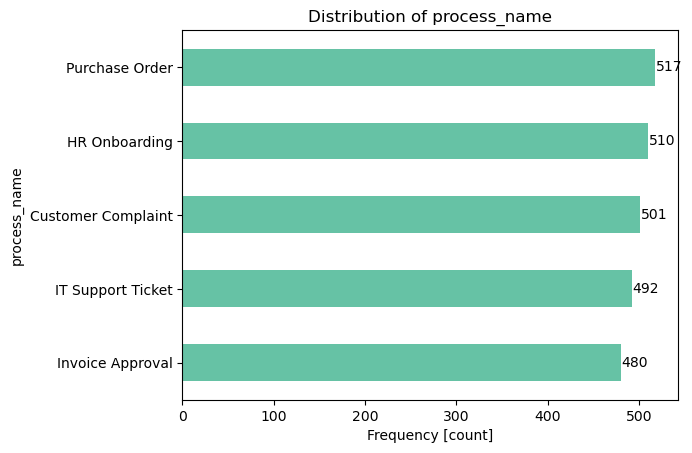

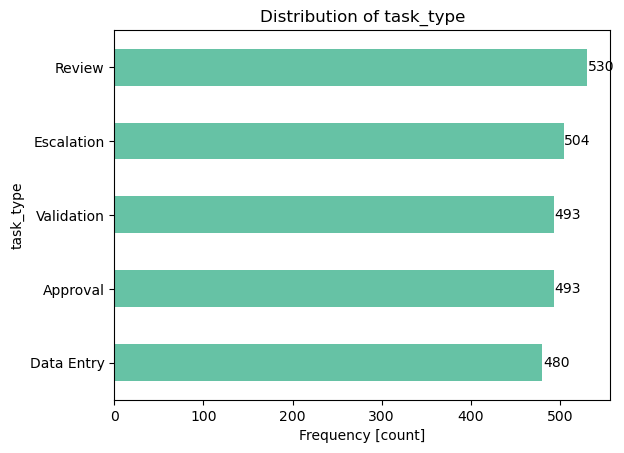

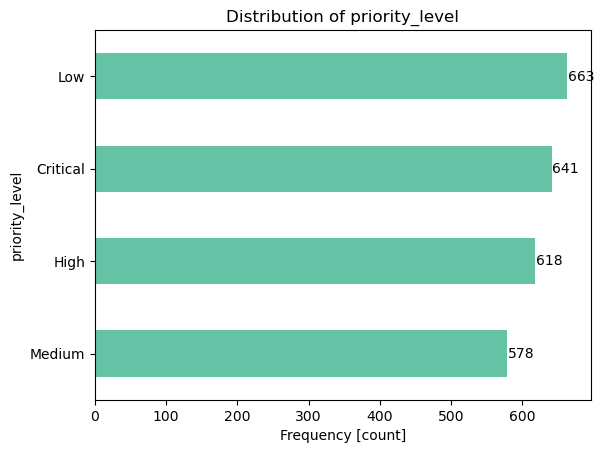

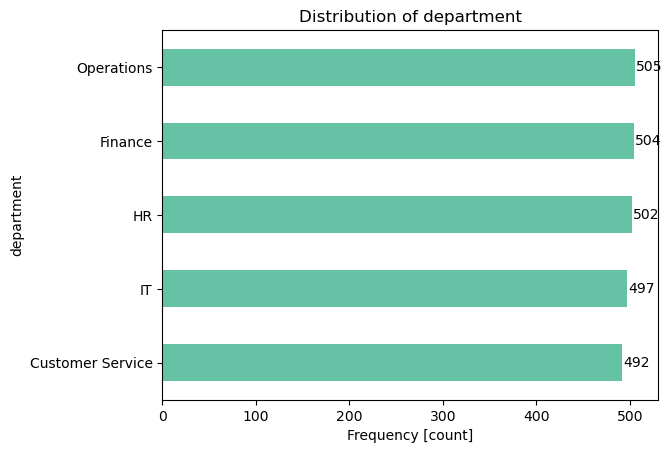

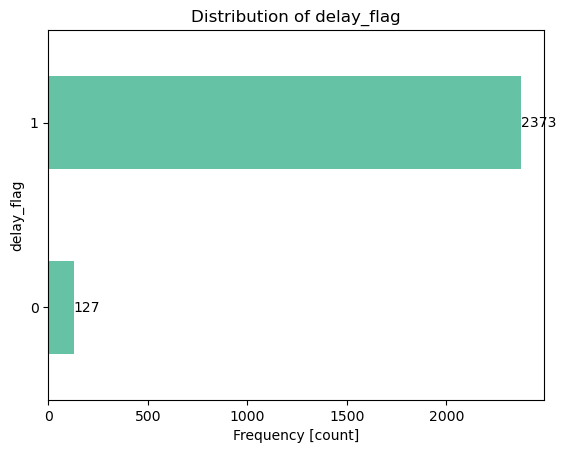

In [50]:
# Categorical columns

categorical_columns = [
    "process_name",
    "task_type",
    "priority_level",
    "department",
    "delay_flag"
]

# Barchart for categorical columns 

for column in categorical_columns:
    df_clean[column].value_counts().sort_values(ascending=True).plot(kind="barh", colormap="Set2")
    
    # Add data labels
    for i, v in enumerate(df_clean[column].value_counts().sort_values(ascending=True)):
        plt.text(v + 1, i, str(v), va="center")

    
    plt.title(f"Distribution of {column}")
    plt.xlabel("Frequency [count]")
    plt.ylabel(column)
    plt.show()

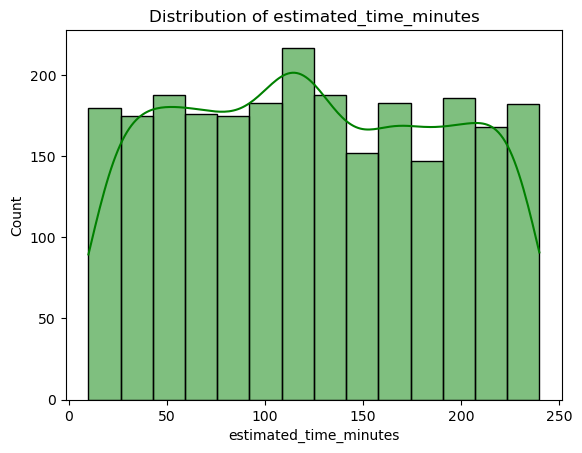

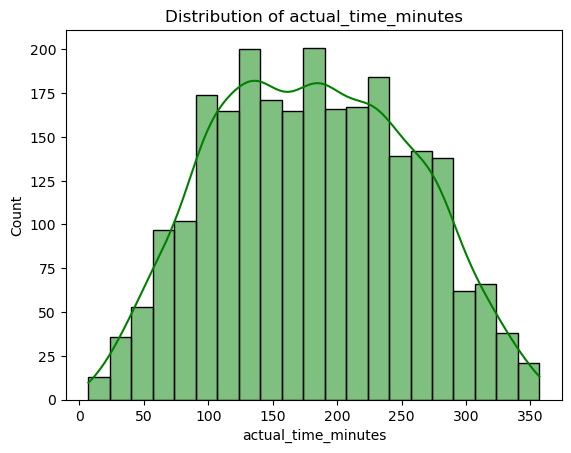

In [ ]:
# Numerical columns

numerical_columns = [
    "estimated_time_minutes",
    "actual_time_minutes"
]

# Histogram for numerical columns with kde 

for column in numerical_columns:    
    sns.histplot(df_clean[column], kde=True,color="green")    
    plt.title(f"Distribution of {column}")    
    plt.xlabel(column)    
    plt.show()

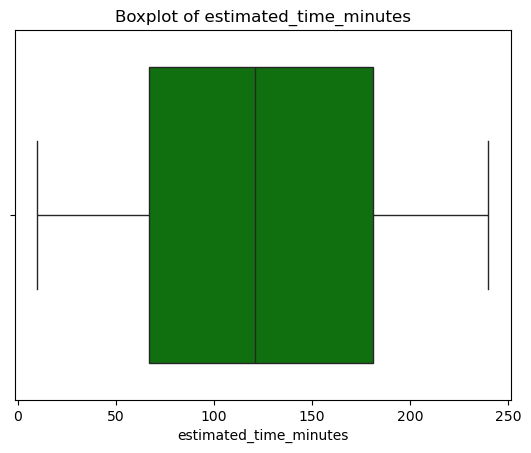

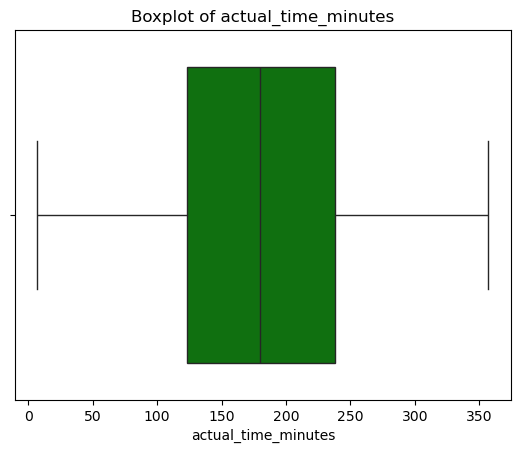

In [68]:
# Checking outliers using boxplot

for column in numerical_columns:
    sns.boxplot(df_clean[column], color="green", orient="h")
    plt.title(f"Boxplot of {column}")
    plt.show()

### b). Bi-variate analysis

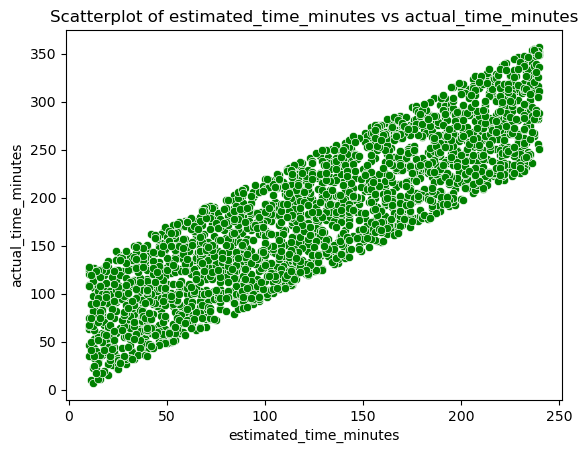

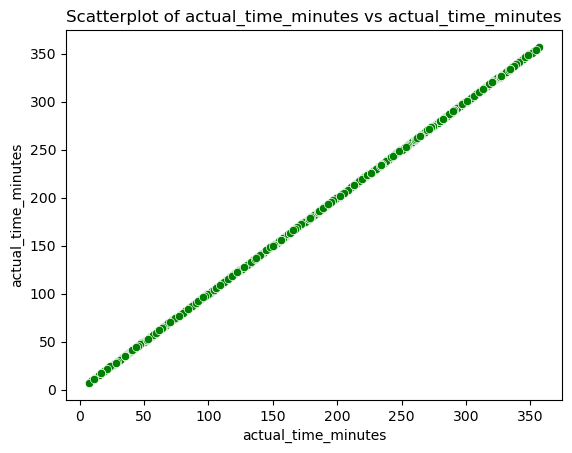

In [71]:
# Numeric vs Numeric

for column in numerical_columns:
    sns.scatterplot(x=df_clean[column], y=df_clean["actual_time_minutes"], color="green")
    plt.title(f"Scatterplot of {column} vs actual_time_minutes")
    plt.xlabel(column)
    plt.ylabel("actual_time_minutes")
    plt.show()

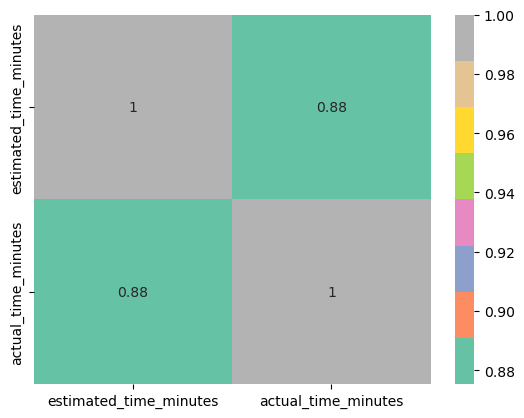

In [77]:
# Correlation Heatmap for numerical columns

corr = df_clean[numerical_columns].corr()
sns.heatmap(corr, annot=True, cmap="Set2")
plt.show()

## 4. Business Questions

#### Are Priority tasks handled in the shortest time possible?

C:\Users\HP\AppData\Local\Temp\ipykernel_18764\2441418475.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("priority_level")["actual_time_minutes"]


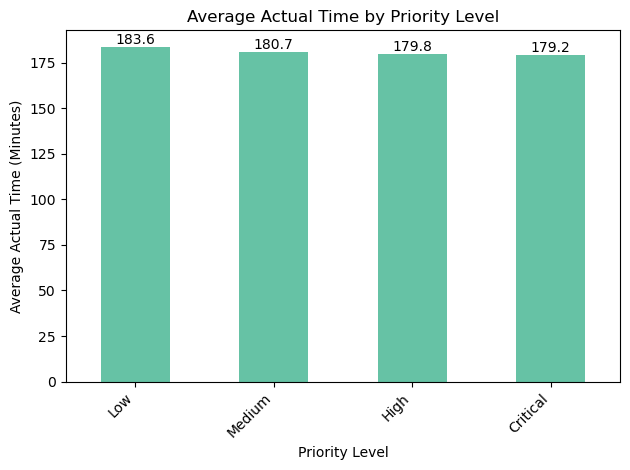

In [92]:
priority_order = ["Low", "Medium", "High", "Critical"]

# Ensure ordered categorical
df_clean["priority_level"] = pd.Categorical(
    df_clean["priority_level"],
    categories=priority_order,
    ordered=True
)

# Group by priority and compute mean actual time
priority_actual_time = (
    df_clean
    .groupby("priority_level")["actual_time_minutes"]
    .mean()
    .sort_index()
)

# Plot
ax = priority_actual_time.plot(
    kind="bar",
    colormap="Set2"
)

plt.xlabel("Priority Level")
plt.ylabel("Average Actual Time (Minutes)")
plt.title("Average Actual Time by Priority Level")

# Rotate x labels
plt.xticks(rotation=45, ha="right")

# Add value labels
for i, value in enumerate(priority_actual_time):
    ax.text(i, value, f"{value:.1f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

#### Which workflows or processes have the highest cost-per-task, and are these costs justified by priority level or complexity?

In [97]:
# Check the distribution of delays
print("Delay Flag distribution:")
print(df['Delay_Flag'].value_counts())
print(f"\nDelay rate: {df['Delay_Flag'].mean():.2%}")

# Check workload variance
print(f"\nWorkload stats:")
print(df['Employee_Workload'].describe())

# Check relationship
print("\nDelay rate by workload:")
print(df.groupby('Employee_Workload')['Delay_Flag'].mean().sort_index())

Delay Flag distribution:
Delay_Flag
1    2373
0     127
Name: count, dtype: int64

Delay rate: 94.92%

Workload stats:
count    2500.000000
mean        5.520400
std         2.842115
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: Employee_Workload, dtype: float64

Delay rate by workload:
Employee_Workload
1     0.964286
2     0.952174
3     0.929167
4     0.968000
5     0.948339
6     0.941860
7     0.949020
8     0.952381
9     0.933333
10    0.953586
Name: Delay_Flag, dtype: float64


Chi-square statistic: 1.4479
P-value: 0.8358
Significant at 0.05 level: False

Optimal workload threshold: 1.00


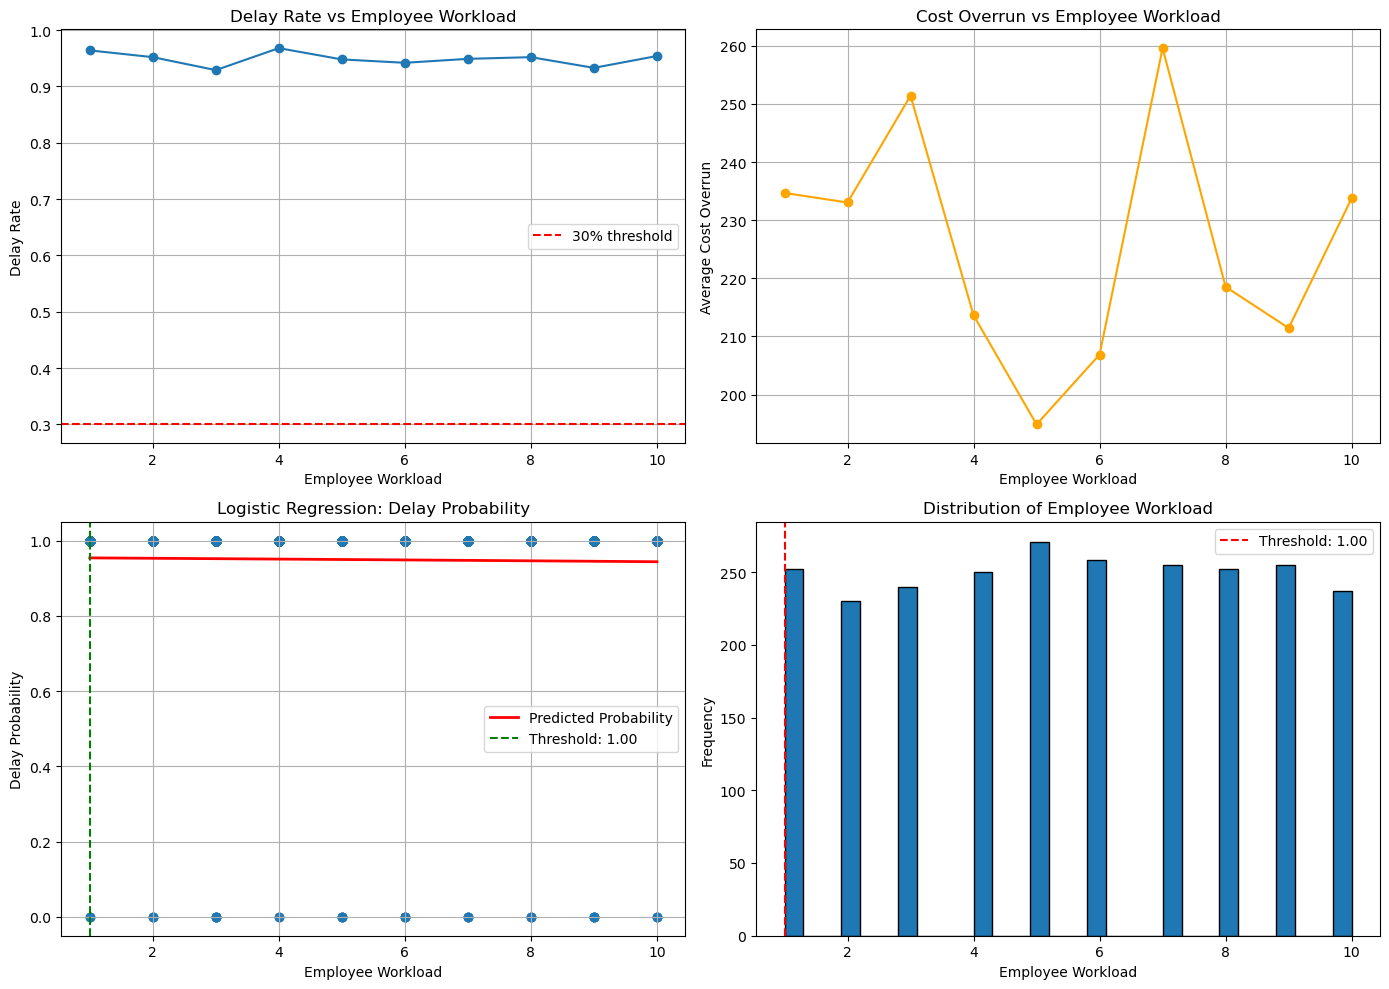


=== WORKLOAD ANALYSIS SUMMARY ===


,Delay_Flag_sum,Delay_Flag_count,Delay_Flag_mean,Cost_Per_Task_mean,Actual_Time_Minutes_mean,Estimated_Time_Minutes_mean,delay_rate
Employee_Workload,,,,,,,
1,243,252,0.964,268.758,176.532,116.921,0.964
2,219,230,0.952,270.927,180.565,123.687,0.952
3,223,240,0.929,283.297,188.654,131.342,0.929
4,242,250,0.968,284.129,180.652,123.100,0.968
5,257,271,0.948,279.393,179.000,126.336,0.948
6,243,258,0.942,277.202,182.314,125.213,0.942
7,242,255,0.949,279.750,180.949,123.255,0.949
8,240,252,0.952,287.022,183.091,125.147,0.952
9,238,255,0.933,265.565,180.396,126.714,0.933



Statistical Significance: p-value = 0.8358
Recommended Maximum Workload: 1.00


In [ ]:
# Calculate delay rate and cost overrun by workload level
workload_analysis = df.groupby('Employee_Workload').agg({
    'Delay_Flag': ['sum', 'count', 'mean'],  # Total delays, total tasks, delay rate
    'Cost_Per_Task': 'mean',
    'Actual_Time_Minutes': 'mean',
    'Estimated_Time_Minutes': 'mean'
}).round(3)

workload_analysis.columns = ['_'.join(col) for col in workload_analysis.columns]
workload_analysis['delay_rate'] = workload_analysis['Delay_Flag_mean']

# Calculate cost overrun (actual vs estimated time * cost)
df['time_variance'] = df['Actual_Time_Minutes'] - df['Estimated_Time_Minutes']
df['cost_overrun'] = (df['time_variance'] / df['Estimated_Time_Minutes']) * df['Cost_Per_Task']

cost_overrun_by_workload = df.groupby('Employee_Workload')['cost_overrun'].mean()

# Statistical significance testing - Chi-square for delay rates
df['workload_bin'] = pd.cut(df['Employee_Workload'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

contingency_table = pd.crosstab(df['workload_bin'], df['Delay_Flag'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant at 0.05 level: {p_value < 0.05}")

# 4. Find the threshold using logistic regression or visual inspection
from sklearn.linear_model import LogisticRegression

X = df[['Employee_Workload']].values
y = df['Delay_Flag'].values

model = LogisticRegression()
model.fit(X, y)

# Predict probabilities across workload range
workload_range = np.linspace(df['Employee_Workload'].min(), 
                              df['Employee_Workload'].max(), 100).reshape(-1, 1)
delay_probabilities = model.predict_proba(workload_range)[:, 1]

# Find threshold where delay probability exceeds acceptable level (e.g., 30%)
threshold_workload = workload_range[delay_probabilities > 0.3][0][0]

print(f"\nOptimal workload threshold: {threshold_workload:.2f}")

# 5. Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Delay rate by workload
axes[0, 0].plot(workload_analysis.index, workload_analysis['delay_rate'], marker='o')
axes[0, 0].axhline(y=0.3, color='r', linestyle='--', label='30% threshold')
axes[0, 0].set_xlabel('Employee Workload')
axes[0, 0].set_ylabel('Delay Rate')
axes[0, 0].set_title('Delay Rate vs Employee Workload')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Cost overrun by workload
axes[0, 1].plot(cost_overrun_by_workload.index, cost_overrun_by_workload.values, marker='o', color='orange')
axes[0, 1].set_xlabel('Employee Workload')
axes[0, 1].set_ylabel('Average Cost Overrun')
axes[0, 1].set_title('Cost Overrun vs Employee Workload')
axes[0, 1].grid(True)

# Plot 3: Logistic regression curve
axes[1, 0].scatter(df['Employee_Workload'], df['Delay_Flag'], alpha=0.3)
axes[1, 0].plot(workload_range, delay_probabilities, color='red', linewidth=2, label='Predicted Probability')
axes[1, 0].axvline(x=threshold_workload, color='green', linestyle='--', label=f'Threshold: {threshold_workload:.2f}')
axes[1, 0].set_xlabel('Employee Workload')
axes[1, 0].set_ylabel('Delay Probability')
axes[1, 0].set_title('Logistic Regression: Delay Probability')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: Distribution of workload
axes[1, 1].hist(df['Employee_Workload'], bins=30, edgecolor='black')
axes[1, 1].axvline(x=threshold_workload, color='red', linestyle='--', label=f'Threshold: {threshold_workload:.2f}')
axes[1, 1].set_xlabel('Employee Workload')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Employee Workload')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 6. Summary statistics
print("\n  WORKLOAD ANALYSIS SUMMARY  ")
display(workload_analysis)
print(f"\nStatistical Significance: p-value = {p_value:.4f}")
print(f"Recommended Maximum Workload: {threshold_workload:.2f}")

**Employee workload is NOT the driver of delay. Since even employees with workload=1 have 96% delay rates, the problem is systemic, not workload-related.**

In [101]:
# Even if everything is delayed, some delays might be worse than others
df['cost_overrun'] = df['Actual_Time_Minutes'] * df['Cost_Per_Task']
df['estimated_cost'] = df['Estimated_Time_Minutes'] * df['Cost_Per_Task']
df['cost_variance'] = df['cost_overrun'] - df['estimated_cost']


# Multi-dimensional delay analysis
delay_drivers = df.groupby(['Department', 'Task_Type', 'Approval_Level']).agg({
    'Delay_Flag': 'mean',
    'delay_magnitude': 'mean',
    'cost_variance': 'sum',
    'Task_ID': 'count'
}).round(3)

delay_drivers.columns = ['delay_rate', 'avg_delay_mins', 'total_cost_impact', 'task_count']
delay_drivers = delay_drivers.sort_values('avg_delay_mins', ascending=False)

print("Top delay drivers:")
display(delay_drivers.head(10))

Top delay drivers:


delay_rate  avg_delay_mins  \
Department       Task_Type  Approval_Level                               
Finance          Escalation Level 2              0.949          69.333   
                 Review     Level 3              0.933          65.033   
IT               Data Entry Level 3              1.000          65.027   
Finance          Review     Level 1              0.971          63.941   
Customer Service Validation Level 2              0.906          63.000   
Finance          Validation Level 3              0.970          62.636   
HR               Escalation Level 3              0.972          62.444   
IT               Review     Level 1              0.931          62.207   
HR               Review     Level 3              0.943          62.171   
Customer Service Review     Level 2              0.917          62.125   

                                            total_cost_impact  task_count  
Department       Task_Type  Approval_Level                                 
Finance          Escalation Level 2                 754143.46          39  
                 Review     Level 3                 472204.75          30  
IT               Data Entry Level 3                 615943.50          37  
Finance          Review     Level 1                 634848.79          34  
Customer Service Validation Level 2                 573487.39          32  
Finance          Validation Level 3                 610392.23          33  
HR               Escalation Level 3                 565441.78          36  
IT               Review     Level 1                 599904.96          29  
HR               Review     Level 3                 645480.93          35  
Customer Service Review     Level 2                 339752.61          24

**The delay rate is 95% and is mainly caused by multi-level approval bottlenecks, with Level 3 approvals being a problem in 6 of the 10 worst-performing process combinations. Finance department processes are the worst, with only 3 Finance-related processes (99 tasks total) contributing more than $500K to delay costs. The first priority should be to eliminate or optimize Level 3 approvals, especially Finance review/escalations and IT data entry, which have a systematic failure rate (93-100% failure rate) and are costly ($65-69 minutes per task).**

### How does actual task completion time compare to estimated time across different task types, and where are we consistently over or underestimating?

=== OVERALL ESTIMATION ACCURACY ===
Average estimation error: 56.95 minutes
Percentage error: 80.17%
Median error: 57.00 minutes

Estimation accuracy breakdown:
estimation_accuracy
Underestimated    94.92
Overestimated      4.12
Accurate           0.96
Name: proportion, dtype: float64

=== ESTIMATION ACCURACY BY TASK TYPE ===
            avg_error_mins  median_error_mins  std_error  avg_error_pct  \
Task_Type                                                                 
Review               60.50               64.0      35.60          89.61   
Approval             55.78               54.0      36.35          84.44   
Escalation           57.19               55.0      38.11          78.98   
Data Entry           55.72               55.0      37.01          76.73   
Validation           55.27               55.0      35.52          70.32   

            median_error_pct  avg_estimated  avg_actual  task_count  abs_error  
Task_Type                                                        

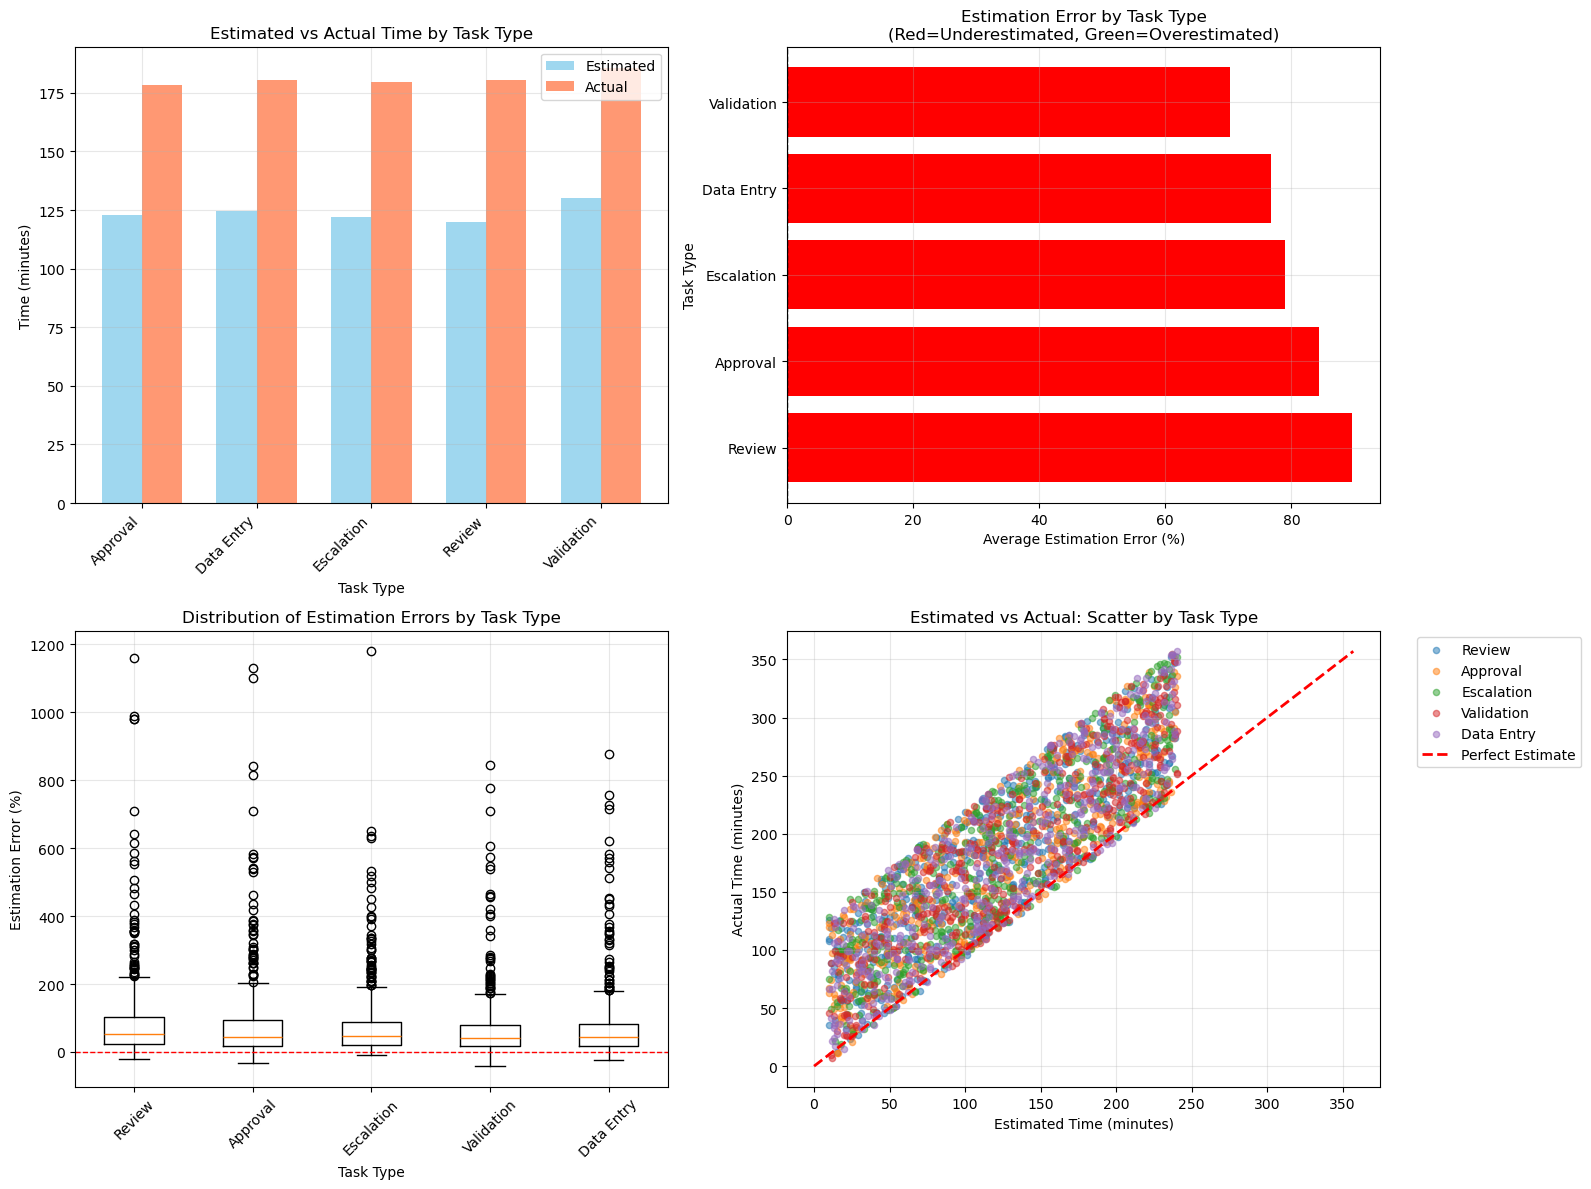


ESTIMATION ACCURACY BY TASK TYPE & PRIORITY
                           estimation_error_pct  Task_ID
Task_Type  Priority_Level                               
Review     Critical                       95.28      122
           High                           95.23      142
           Medium                         92.96      115
Validation Critical                       91.06      130
Escalation Low                            89.51      118
Approval   Critical                       87.79      128
           Low                            87.48      122
           Medium                         86.35      126
Data Entry High                           81.40      124
Escalation Critical                       81.05      131
Data Entry Critical                       79.22      130
           Low                            78.80      127
Escalation High                           77.59      129
Review     Low                            77.18      151
Approval   High                           7

In [ ]:
# 1. Calculate estimation errors
df['time_difference'] = df['Actual_Time_Minutes'] - df['Estimated_Time_Minutes']
df['estimation_error_pct'] = (df['time_difference'] / df['Estimated_Time_Minutes']) * 100
df['estimation_accuracy'] = np.where(df['time_difference'] > 0, 'Underestimated', 
                                      np.where(df['time_difference'] < 0, 'Overestimated', 'Accurate'))

# 2. Overall estimation performance
print("OVERALL ESTIMATION ACCURACY")
print(f"Average estimation error: {df['time_difference'].mean():.2f} minutes")
print(f"Percentage error: {df['estimation_error_pct'].mean():.2f}%")
print(f"Median error: {df['time_difference'].median():.2f} minutes")
print(f"\nEstimation accuracy breakdown:")
print(df['estimation_accuracy'].value_counts(normalize=True) * 100)

# 3. Estimation accuracy by Task Type
task_type_analysis = df.groupby('Task_Type').agg({
    'time_difference': ['mean', 'median', 'std'],
    'estimation_error_pct': ['mean', 'median'],
    'Estimated_Time_Minutes': 'mean',
    'Actual_Time_Minutes': 'mean',
    'Task_ID': 'count'
}).round(2)

task_type_analysis.columns = ['avg_error_mins', 'median_error_mins', 'std_error', 
                                'avg_error_pct', 'median_error_pct', 
                                'avg_estimated', 'avg_actual', 'task_count']

# Sort by worst estimation errors
task_type_analysis['abs_error'] = task_type_analysis['avg_error_mins'].abs()
task_type_analysis = task_type_analysis.sort_values('avg_error_pct', ascending=False)

print("\n=== ESTIMATION ACCURACY BY TASK TYPE ===")
print(task_type_analysis)

# 4. Identify consistent patterns
print("\n=== CONSISTENTLY UNDERESTIMATED TASKS ===")
underestimated = task_type_analysis[task_type_analysis['avg_error_mins'] > 0].sort_values(
    'avg_error_pct', ascending=False)
print(underestimated)

print("\n=== CONSISTENTLY OVERESTIMATED TASKS ===")
overestimated = task_type_analysis[task_type_analysis['avg_error_mins'] < 0].sort_values(
    'avg_error_pct', ascending=True)
print(overestimated)

# 5. Statistical significance testing
# Test if estimation errors differ significantly across task types
task_groups = [group['time_difference'].values for name, group in df.groupby('Task_Type')]
f_stat, p_value = stats.f_oneway(*task_groups)

print(f"\n=== STATISTICAL SIGNIFICANCE ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant differences across task types: {p_value < 0.05}")

# 6. Cross-dimensional analysis (Task Type + Department)
cross_analysis = df.groupby(['Task_Type', 'Department']).agg({
    'time_difference': 'mean',
    'estimation_error_pct': 'mean',
    'Task_ID': 'count'
}).round(2)

cross_analysis.columns = ['avg_error_mins', 'avg_error_pct', 'task_count']
cross_analysis = cross_analysis[cross_analysis['task_count'] >= 10]  # Filter for significance
cross_analysis = cross_analysis.sort_values('avg_error_pct', ascending=False)

print("\n=== WORST ESTIMATION ERRORS BY TASK TYPE + DEPARTMENT ===")
print(cross_analysis.head(10))

# 7. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Actual vs Estimated by Task Type
task_summary = df.groupby('Task_Type')[['Estimated_Time_Minutes', 'Actual_Time_Minutes']].mean()
x = np.arange(len(task_summary))
width = 0.35

axes[0, 0].bar(x - width/2, task_summary['Estimated_Time_Minutes'], width, 
               label='Estimated', color='skyblue', alpha=0.8)
axes[0, 0].bar(x + width/2, task_summary['Actual_Time_Minutes'], width, 
               label='Actual', color='coral', alpha=0.8)
axes[0, 0].set_xlabel('Task Type')
axes[0, 0].set_ylabel('Time (minutes)')
axes[0, 0].set_title('Estimated vs Actual Time by Task Type')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(task_summary.index, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Error percentage by task type
axes[0, 1].barh(task_type_analysis.index, task_type_analysis['avg_error_pct'], 
                color=['red' if x > 0 else 'green' for x in task_type_analysis['avg_error_pct']])
axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Average Estimation Error (%)')
axes[0, 1].set_ylabel('Task Type')
axes[0, 1].set_title('Estimation Error by Task Type\n(Red=Underestimated, Green=Overestimated)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution of estimation errors by task type (box plot)
task_types = df['Task_Type'].unique()
data_to_plot = [df[df['Task_Type'] == task]['estimation_error_pct'].values 
                for task in task_types]

axes[1, 0].boxplot(data_to_plot, labels=task_types)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Task Type')
axes[1, 0].set_ylabel('Estimation Error (%)')
axes[1, 0].set_title('Distribution of Estimation Errors by Task Type')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Scatter plot - Estimated vs Actual time
for task_type in df['Task_Type'].unique():
    task_data = df[df['Task_Type'] == task_type]
    axes[1, 1].scatter(task_data['Estimated_Time_Minutes'], 
                      task_data['Actual_Time_Minutes'], 
                      alpha=0.5, label=task_type, s=20)

# Add perfect estimation line
max_time = max(df['Estimated_Time_Minutes'].max(), df['Actual_Time_Minutes'].max())
axes[1, 1].plot([0, max_time], [0, max_time], 'r--', linewidth=2, label='Perfect Estimate')
axes[1, 1].set_xlabel('Estimated Time (minutes)')
axes[1, 1].set_ylabel('Actual Time (minutes)')
axes[1, 1].set_title('Estimated vs Actual: Scatter by Task Type')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Priority-based analysis (does priority affect estimation?)
priority_estimation = df.groupby(['Task_Type', 'Priority_Level']).agg({
    'estimation_error_pct': 'mean',
    'Task_ID': 'count'
}).round(2)

print("\nESTIMATION ACCURACY BY TASK TYPE & PRIORITY")
print(priority_estimation[priority_estimation['Task_ID'] >= 5].sort_values(
    'estimation_error_pct', ascending=False).head(15))

# 9. Summary insights
print("\n=== KEY INSIGHTS ===")
worst_task = task_type_analysis.nlargest(1, 'avg_error_pct').index[0]
worst_error = task_type_analysis.nlargest(1, 'avg_error_pct')['avg_error_pct'].values[0]

best_task = task_type_analysis.nsmallest(1, 'abs_error').index[0]
best_error = task_type_analysis.nsmallest(1, 'abs_error')['avg_error_pct'].values[0]

print(f"Worst estimated task type: {worst_task} ({worst_error:.1f}% error)")
print(f"Best estimated task type: {best_task} ({best_error:.1f}% error)")
print(f"\nOverall, tasks are {df['estimation_error_pct'].mean():.1f}% underestimated on average")
print(f"Total cost of estimation errors: ${df['time_difference'].sum() * df['Cost_Per_Task'].mean():,.2f}")

**All types of tasks are systematically underestimated by 60-90%, and actual times taken are always 40-55 minutes longer than estimated.** The accuracy of Review tasks is the poorest at 90% underestimation, while even the "best" type of task (Validation) is still 63% underestimation, and there are some tasks that are catastrophic outliers with error margins of 1000%+ or more. **The problem seems to be that the estimates are not taking into account the approval delays, handoffs, and dependencies, or "hidden work" that adds 40-55 minutes to every task.**

#### What is the cost-efficiency ratio across departments when controlling for task priority and type - which departments deliver the best value per unit of time invested?

In [106]:
X = df[['dept_encoded', 'task_encoded', 'Priority_Numeric']]

Unique priority levels: ['Low' 'High' 'Medium' 'Critical']
=== OVERALL DEPARTMENT EFFICIENCY ===


,avg_cost,avg_time,cost_per_min,efficiency_score,delay_rate,task_count
Department,,,,,,
Customer Service,273.90,179.54,1.99,0.67,0.94,492
Operations,280.76,181.62,2.04,0.67,0.95,505
HR,277.11,181.70,2.09,0.68,0.95,502
IT,283.01,185.15,2.10,0.68,0.95,497
Finance,275.07,176.34,2.11,0.65,0.95,504



=== DEPARTMENT EFFICIENCY CONTROLLING FOR TASK TYPE ===

Best performers (by task type):


avg_cost  avg_time  cost_per_min  task_count
Department       Task_Type                                               
Customer Service Review        269.78    192.30          1.67         101
IT               Approval      273.56    190.14          1.75          95
Operations       Data Entry    262.20    184.71          1.85         101
Finance          Escalation    276.33    191.68          1.86         120
IT               Escalation    271.97    189.48          1.88          88
HR               Validation    271.25    184.86          1.89         100
Operations       Escalation    277.00    179.11          1.90         106
                 Validation    270.83    190.90          1.91         101
HR               Review        277.63    186.14          1.92         107
Customer Service Validation    293.43    192.61          1.96          93


Worst performers (by task type):


...

avg_cost  avg_time  cost_per_min  \
Department       Task_Type  Priority_Level                                     
Customer Service Approval   Low               261.09    163.62          2.48   
Finance          Escalation Low               287.02    174.26          2.48   
                 Review     High              242.61    156.40          2.49   
Operations       Approval   Critical          304.22    169.67          2.49   
IT               Review     Medium            303.65    176.14          2.53   
Finance          Data Entry Medium            254.32    164.75          2.54   
Operations       Approval   High              317.27    185.47          2.59   
HR               Approval   Critical          293.03    164.15          2.65   
Operations       Review     Low               258.74    174.16          2.69   
IT               Validation Medium            334.18    165.70          2.77   
Operations       Data Entry High              294.62    159.95          3.04   
HR               Data Entry High              286.73    176.91          3.06   
Customer Service Escalation High              246.69    105.88          3.09   
Finance          Validation Critical          341.61    181.41          3.44   
IT               Validation High              303.10    192.96          3.66   

                                            delay_rate  task_count  
Department       Task_Type  Priority_Level                          
Customer Service Approval   Low                   0.88          26  
Finance          Escalation Low                   0.96          23  
                 Review     High                  0.96          25  
Operations       Approval   Critical              0.96          27  
IT               Review     Medium                1.00          22  
Finance          Data Entry Medium                1.00          16  
Operations       Approval   High                  1.00          19  
HR               Approval   Critical              1.00          26  
Operations       Review     Low                   0.91          32  
IT               Validation Medium                0.96          23  
Operations       Data Entry High                  0.95          19  
HR               Data Entry High                  0.95          22  
Customer Service Escalation High                  0.81          16  
Finance          Validation Critical              0.93          29  
IT               Validation High                  0.96          24


=== DEPARTMENT COST EFFECTS (STATISTICALLY CONTROLLED) ===
Lower coefficient = more cost-efficient


,Department,dept_coefficient
0,Customer Service,0.004523
1,Finance,0.004523
2,HR,0.004523
3,IT,0.004523
4,Operations,0.004523



=== COMPOSITE VALUE SCORE ===


,cost_score,time_score,quality_score,value_score
Department,,,,
Customer Service,100.000000,63.714805,6.1,60.944441
Operations,63.559322,40.065849,5.1,38.973484
Finance,0.000000,100.000000,4.8,31.440000
HR,22.033898,39.237057,4.8,22.024676
IT,14.406780,0.000000,4.6,7.142712


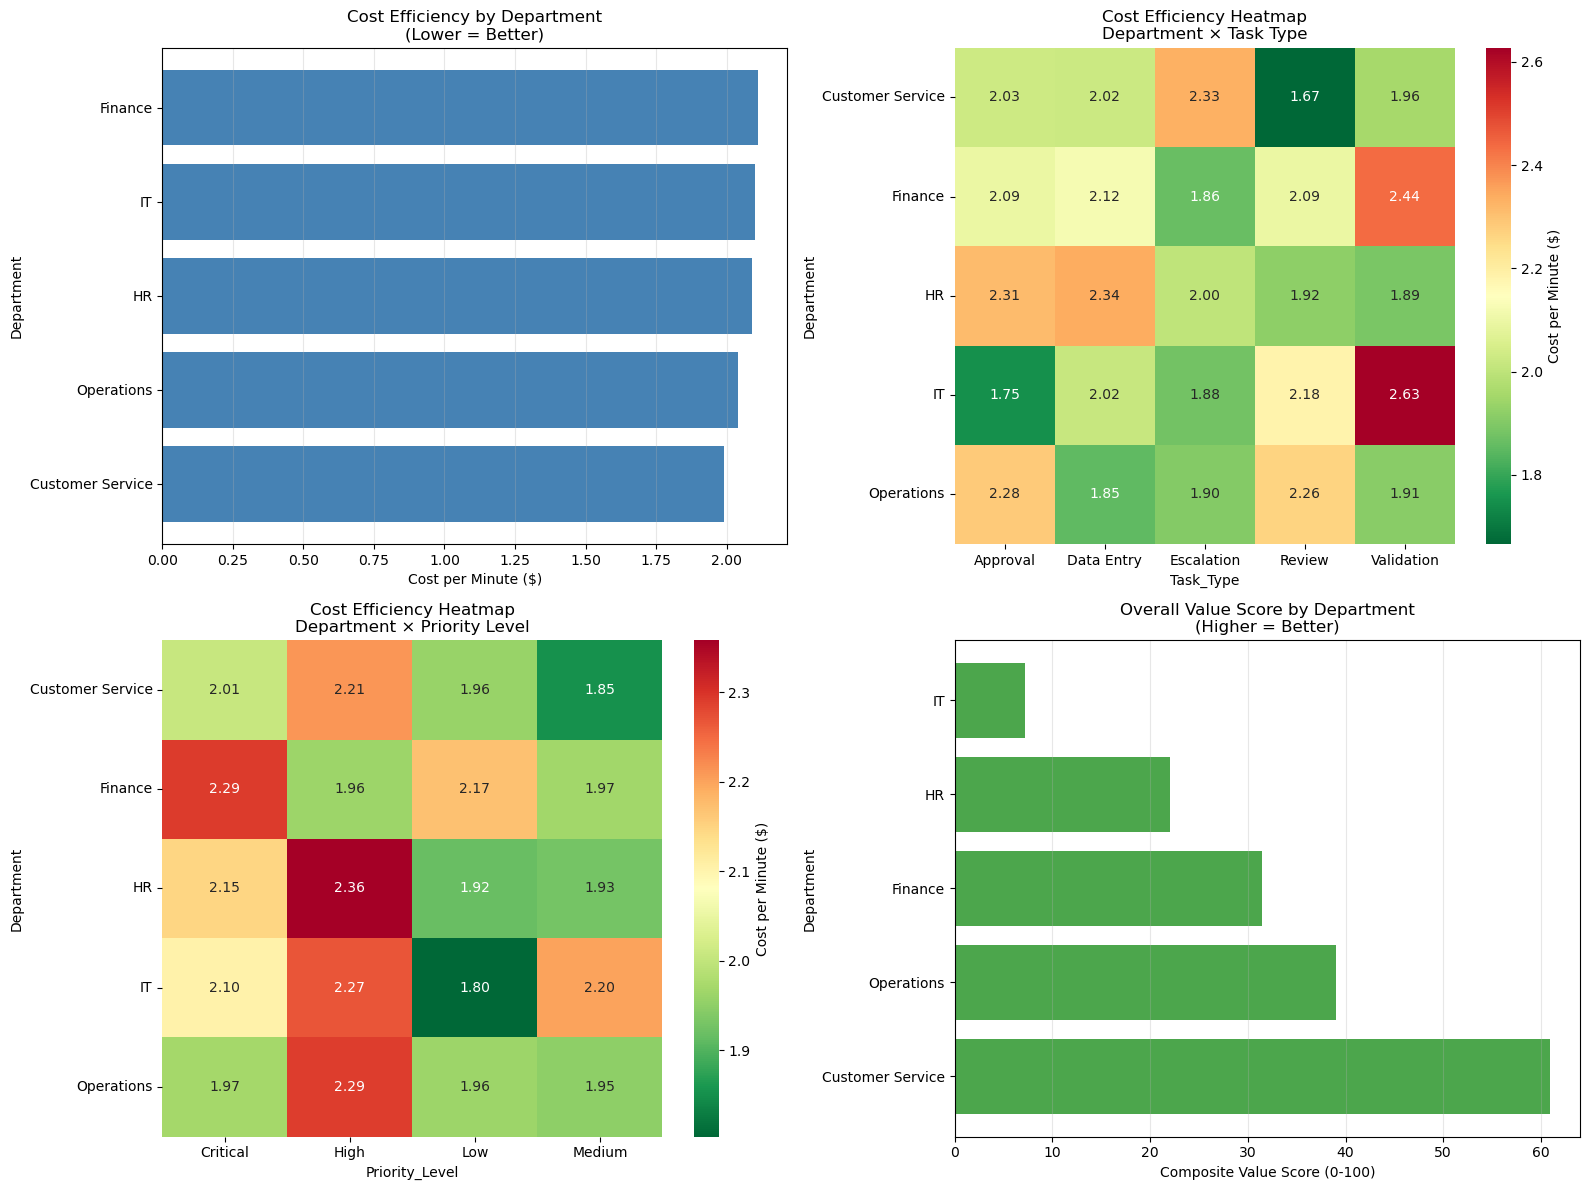


=== APPLES-TO-APPLES COMPARISON ===
For the SAME task type and priority, which department is most efficient?



'Approval (Priority: Critical):'

,cost_per_minute,Actual_Time_Minutes,Task_ID
Department,,,
Customer Service,1.73,179.23,22
Finance,2.21,167.20,35
IT,2.42,170.22,18
Operations,2.49,169.67,27
HR,2.65,164.15,26


'Approval (Priority: High):'

,cost_per_minute,Actual_Time_Minutes,Task_ID
Department,,,
IT,1.53,201.19,27
Customer Service,2.11,205.00,21
HR,2.27,173.78,27
Finance,2.31,156.87,23
Operations,2.59,185.47,19


...

'Approval (Priority: Medium):'

,cost_per_minute,Actual_Time_Minutes,Task_ID
Department,,,
Finance,1.78,182.96,24
Customer Service,1.79,179.29,28
IT,1.79,168.53,30
Operations,1.92,178.47,19
HR,2.34,188.36,25


'Data Entry (Priority: Critical):'

,cost_per_minute,Actual_Time_Minutes,Task_ID
Department,,,
Operations,1.60,198.63,38
IT,1.74,204.56,18
HR,2.05,179.32,25
Finance,2.19,154.00,22
Customer Service,2.25,169.93,27



=== STATISTICAL SIGNIFICANCE ===
F-statistic: 0.2080
P-value: 0.9341
Significant differences: False

EXECUTIVE SUMMARY: DEPARTMENT COST-EFFICIENCY

Most Efficient: Customer Service
  Cost per minute: $1.99
  Delay rate: 94.0%

Least Efficient: Finance
  Cost per minute: $2.11
  Delay rate: 95.0%

Gap: Finance costs 6.0% more per minute than Customer Service


In [112]:
from sklearn.preprocessing import LabelEncoder

# 1. Encode Priority_Level as numeric
priority_mapping = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['Priority_Numeric'] = df['Priority_Level'].map(priority_mapping)

# If your priority levels have different names, check them first:
print("Unique priority levels:", df['Priority_Level'].unique())

# 2. Define cost-efficiency metrics
df['time_per_dollar'] = df['Actual_Time_Minutes'] / df['Cost_Per_Task']
df['cost_per_minute'] = df['Cost_Per_Task'] / df['Actual_Time_Minutes']
df['efficiency_score'] = df['Estimated_Time_Minutes'] / df['Actual_Time_Minutes']

# 3. Overall department efficiency
print("=== OVERALL DEPARTMENT EFFICIENCY ===")
dept_efficiency = df.groupby('Department').agg({
    'Cost_Per_Task': 'mean',
    'Actual_Time_Minutes': 'mean',
    'cost_per_minute': 'mean',
    'efficiency_score': 'mean',
    'Delay_Flag': 'mean',
    'Task_ID': 'count'
}).round(2)

dept_efficiency.columns = ['avg_cost', 'avg_time', 'cost_per_min', 
                           'efficiency_score', 'delay_rate', 'task_count']
dept_efficiency = dept_efficiency.sort_values('cost_per_min', ascending=True)
display(dept_efficiency)

# 4. CONTROL FOR TASK TYPE
print("\n=== DEPARTMENT EFFICIENCY CONTROLLING FOR TASK TYPE ===")
dept_task_efficiency = df.groupby(['Department', 'Task_Type']).agg({
    'Cost_Per_Task': 'mean',
    'Actual_Time_Minutes': 'mean',
    'cost_per_minute': 'mean',
    'Task_ID': 'count'
}).round(2)

dept_task_efficiency.columns = ['avg_cost', 'avg_time', 'cost_per_min', 'task_count']
dept_task_efficiency = dept_task_efficiency[dept_task_efficiency['task_count'] >= 10]
dept_task_efficiency = dept_task_efficiency.sort_values('cost_per_min', ascending=True)

print("\nBest performers (by task type):")
display(dept_task_efficiency.head(10))
print("\nWorst performers (by task type):")
display(dept_task_efficiency.tail(10))

# 5. CONTROL FOR PRIORITY
print("\n=== DEPARTMENT EFFICIENCY CONTROLLING FOR PRIORITY ===")
dept_priority_efficiency = df.groupby(['Department', 'Priority_Level']).agg({
    'Cost_Per_Task': 'mean',
    'Actual_Time_Minutes': 'mean',
    'cost_per_minute': 'mean',
    'Task_ID': 'count'
}).round(2)

dept_priority_efficiency.columns = ['avg_cost', 'avg_time', 'cost_per_min', 'task_count']
dept_priority_efficiency = dept_priority_efficiency[dept_priority_efficiency['task_count'] >= 10]
dept_priority_efficiency = dept_priority_efficiency.sort_values('cost_per_min', ascending=True)

print("\nBest performers (by priority):")
display(dept_priority_efficiency.head(10))

# 6. FULL CONTROL - Both task type AND priority
print("\n=== DEPARTMENT EFFICIENCY CONTROLLING FOR TASK TYPE + PRIORITY ===")
dept_full_control = df.groupby(['Department', 'Task_Type', 'Priority_Level']).agg({
    'Cost_Per_Task': 'mean',
    'Actual_Time_Minutes': 'mean',
    'cost_per_minute': 'mean',
    'Delay_Flag': 'mean',
    'Task_ID': 'count'
}).round(2)

dept_full_control.columns = ['avg_cost', 'avg_time', 'cost_per_min', 
                              'delay_rate', 'task_count']
dept_full_control = dept_full_control[dept_full_control['task_count'] >= 5]
dept_full_control = dept_full_control.sort_values('cost_per_min', ascending=True)

print("\nMost efficient (controlling for both):")
display(dept_full_control.head(15))
print("\nLeast efficient (controlling for both):")
display(dept_full_control.tail(15))

# 7. Statistical regression controlling for task and priority
le_dept = LabelEncoder()
le_task = LabelEncoder()

df['dept_encoded'] = le_dept.fit_transform(df['Department'])
df['task_encoded'] = le_task.fit_transform(df['Task_Type'])

# Use Priority_Numeric instead of Priority_Level
from sklearn.linear_model import LinearRegression

X = df[['dept_encoded', 'task_encoded', 'Priority_Numeric']].values
y = df['cost_per_minute'].values

model = LinearRegression()
model.fit(X, y)

# Department effects (controlled)
dept_effects = pd.DataFrame({
    'Department': le_dept.classes_,
    'dept_coefficient': model.coef_[0]
})
dept_effects = dept_effects.sort_values('dept_coefficient')

print("\n=== DEPARTMENT COST EFFECTS (STATISTICALLY CONTROLLED) ===")
print("Lower coefficient = more cost-efficient")
display(dept_effects)

# 8. Composite Value Score
print("\n=== COMPOSITE VALUE SCORE ===")
dept_value = df.groupby('Department').agg({
    'cost_per_minute': 'mean',
    'Actual_Time_Minutes': 'mean',
    'Delay_Flag': 'mean',
    'Task_ID': 'count'
}).round(3)

# Normalize scores (0-100)
dept_value['cost_score'] = 100 - ((dept_value['cost_per_minute'] - dept_value['cost_per_minute'].min()) / 
                                   (dept_value['cost_per_minute'].max() - dept_value['cost_per_minute'].min()) * 100)

dept_value['time_score'] = 100 - ((dept_value['Actual_Time_Minutes'] - dept_value['Actual_Time_Minutes'].min()) / 
                                   (dept_value['Actual_Time_Minutes'].max() - dept_value['Actual_Time_Minutes'].min()) * 100)

dept_value['quality_score'] = 100 - (dept_value['Delay_Flag'] * 100)

# Composite: 40% cost, 30% time, 30% quality
dept_value['value_score'] = (dept_value['cost_score'] * 0.4 + 
                             dept_value['time_score'] * 0.3 + 
                             dept_value['quality_score'] * 0.3)

dept_value = dept_value.sort_values('value_score', ascending=False)
display(dept_value[['cost_score', 'time_score', 'quality_score', 'value_score']])

# 9. VISUALIZATIONS
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cost per minute by department
axes[0, 0].barh(dept_efficiency.index, dept_efficiency['cost_per_min'], 
                color='steelblue')
axes[0, 0].set_xlabel('Cost per Minute ($)')
axes[0, 0].set_ylabel('Department')
axes[0, 0].set_title('Cost Efficiency by Department\n(Lower = Better)')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Plot 2: Heatmap - Department vs Task Type
pivot_task = df.pivot_table(values='cost_per_minute', 
                             index='Department', 
                             columns='Task_Type', 
                             aggfunc='mean')
sns.heatmap(pivot_task, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            ax=axes[0, 1], cbar_kws={'label': 'Cost per Minute ($)'})
axes[0, 1].set_title('Cost Efficiency Heatmap\nDepartment × Task Type')

# Plot 3: Heatmap - Department vs Priority
pivot_priority = df.pivot_table(values='cost_per_minute', 
                                 index='Department', 
                                 columns='Priority_Level', 
                                 aggfunc='mean')
sns.heatmap(pivot_priority, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            ax=axes[1, 0], cbar_kws={'label': 'Cost per Minute ($)'})
axes[1, 0].set_title('Cost Efficiency Heatmap\nDepartment × Priority Level')

# Plot 4: Value score
axes[1, 1].barh(dept_value.index, dept_value['value_score'], color='green', alpha=0.7)
axes[1, 1].set_xlabel('Composite Value Score (0-100)')
axes[1, 1].set_ylabel('Department')
axes[1, 1].set_title('Overall Value Score by Department\n(Higher = Better)')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 10. Apples-to-apples comparison
print("\n=== APPLES-TO-APPLES COMPARISON ===")
print("For the SAME task type and priority, which department is most efficient?\n")

common_work = df.groupby(['Task_Type', 'Priority_Level']).size()
common_work = common_work[common_work >= 20].index

for task, priority in list(common_work)[:5]:
    subset = df[(df['Task_Type'] == task) & (df['Priority_Level'] == priority)]
    comparison = subset.groupby('Department').agg({
        'cost_per_minute': 'mean',
        'Actual_Time_Minutes': 'mean',
        'Task_ID': 'count'
    }).round(2)
    
    if len(comparison) > 1:
        display(f"{task} (Priority: {priority}):")
        display(comparison.sort_values('cost_per_minute'))

# 11. Statistical significance
print("\n=== STATISTICAL SIGNIFICANCE ===")
dept_groups = [group['cost_per_minute'].values for name, group in df.groupby('Department')]
f_stat, p_value = stats.f_oneway(*dept_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant differences: {p_value < 0.05}")

# 12. Executive Summary
print("\n" + "="*60)
print("EXECUTIVE SUMMARY: DEPARTMENT COST-EFFICIENCY")
print("="*60)

best_dept = dept_efficiency.index[0]
worst_dept = dept_efficiency.index[-1]
best_cost = dept_efficiency.iloc[0]['cost_per_min']
worst_cost = dept_efficiency.iloc[-1]['cost_per_min']

print(f"\nMost Efficient: {best_dept}")
print(f"  Cost per minute: ${best_cost:.2f}")
print(f"  Delay rate: {dept_efficiency.iloc[0]['delay_rate']:.1%}")

print(f"\nLeast Efficient: {worst_dept}")
print(f"  Cost per minute: ${worst_cost:.2f}")
print(f"  Delay rate: {dept_efficiency.iloc[-1]['delay_rate']:.1%}")

print(f"\nGap: {worst_dept} costs {(worst_cost/best_cost - 1)*100:.1f}% more per minute than {best_dept}")

## 5. Feature Engineering

In [138]:
# Func for feature  engineering


from sklearn.preprocessing import LabelEncoder

def features_engineering(df):
    """
    Feature engineering function for workflow process data.
    
    Creates derived metrics for cost efficiency, estimation accuracy, 
    delays, and composite scores.
    """
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Clean and lowercase all column names
    df.columns = df.columns.str.strip().str.lower()
    
    print("Starting feature engineering...")
    print(f"Columns: {df.columns.tolist()}\n")
    
    # =========================================================================
    # 1. PRIORITY ENCODING
    # =========================================================================
    print("Creating priority features...")
    priority_mapping = {
        'Low': 1, 
        'Medium': 2, 
        'High': 3,
        'Critical': 4
    }
    df['priority_numeric'] = df['priority_level'].map(priority_mapping).astype(float)  # FIX: Convert to float
    
    # Handle any unmapped values
    if df['priority_numeric'].isna().any():
        print(f"  Warning: Unmapped priorities found, filling with median")
        df['priority_numeric'].fillna(df['priority_numeric'].median(), inplace=True)
    
    # =========================================================================
    # 2. TIME-BASED FEATURES
    # =========================================================================
    print("Creating time-based features...")
    df['time_difference'] = df['actual_time_minutes'] - df['estimated_time_minutes']
    df['estimation_error_pct'] = (df['time_difference'] / df['estimated_time_minutes']) * 100
    df['estimation_accuracy'] = np.where(
        df['time_difference'] > 0, 'Underestimated', 
        np.where(df['time_difference'] < 0, 'Overestimated', 'Accurate')
    )
    df['efficiency_score'] = df['estimated_time_minutes'] / df['actual_time_minutes']
    df['delay_magnitude'] = np.where(df['delay_flag'] == 1, df['time_difference'], 0)
    
    # =========================================================================
    # 3. COST-BASED FEATURES
    # =========================================================================
    print("Creating cost-based features...")
    df['cost_per_minute'] = df['cost_per_task'] / df['actual_time_minutes']
    df['time_per_dollar'] = df['actual_time_minutes'] / df['cost_per_task']
    df['estimated_cost'] = df['estimated_time_minutes'] * df['cost_per_task']
    df['actual_cost'] = df['actual_time_minutes'] * df['cost_per_task']
    df['cost_variance'] = df['actual_cost'] - df['estimated_cost']
    df['cost_overrun_pct'] = (df['cost_variance'] / df['estimated_cost']) * 100
    df['delay_cost'] = np.where(df['delay_flag'] == 1, df['cost_variance'], 0)
    
    # =========================================================================
    # 4. WORKLOAD-BASED FEATURES
    # =========================================================================
    print("Creating workload-based features...")
    df['workload_category'] = pd.cut(
        df['employee_workload'],
        bins=[0, 3, 6, 10],
        labels=['Low', 'Medium', 'High']
    )
    df['workload_bin'] = pd.cut(
        df['employee_workload'],
        bins=5,
        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
    )
    
    # =========================================================================
    # 5. TASK COMPLEXITY INDICATORS
    # =========================================================================
    print("Creating complexity features...")
    df['is_complex_task'] = (
        (df['estimated_time_minutes'] > df['estimated_time_minutes'].median()) &
        (df['approval_level'].str.contains('Level 3', na=False)) &
        (df['employee_workload'] > df['employee_workload'].median())
    ).astype(int)
    
    df['is_high_risk'] = (
        (df['priority_numeric'] >= 3) &
        (df['employee_workload'] >= 7)
    ).astype(int)
    
    # =========================================================================
    # 6. CATEGORICAL ENCODINGS (for modeling)
    # =========================================================================
    print("Creating categorical encodings...")
    
    le_dept = LabelEncoder()
    df['dept_encoded'] = le_dept.fit_transform(df['department'])
    
    le_task = LabelEncoder()
    df['task_encoded'] = le_task.fit_transform(df['task_type'])
    
    le_approval = LabelEncoder()
    df['approval_encoded'] = le_approval.fit_transform(df['approval_level'])
    
    df.attrs['dept_encoder'] = le_dept
    df.attrs['task_encoder'] = le_task
    df.attrs['approval_encoder'] = le_approval
    
    # =========================================================================
    # 7. INTERACTION FEATURES
    # =========================================================================
    print("Creating interaction features...")
    df['dept_task_combo'] = df['department'] + '_' + df['task_type']
    
    # FIX: Ensure numeric types for multiplication
    df['priority_workload_score'] = df['priority_numeric'].astype(float) * df['employee_workload'].astype(float)
    
    df['approval_priority_combo'] = df['approval_level'] + '_P' + df['priority_level'].astype(str)
    
    # =========================================================================
    # 8. PERFORMANCE INDICATORS
    # =========================================================================
    print("Creating performance indicators...")
    df['on_time_flag'] = (df['delay_flag'] == 0).astype(int)
    df['severe_delay_flag'] = (df['estimation_error_pct'] > 100).astype(int)
    df['cost_overrun_flag'] = (df['cost_variance'] > 0).astype(int)
    df['extreme_outlier'] = (df['estimation_error_pct'] > 500).astype(int)
    
    # =========================================================================
    # 9. AGGREGATED FEATURES (requires groupby operations)
    # =========================================================================
    print("Creating aggregated features...")
    df['dept_avg_delay_rate'] = df.groupby('department')['delay_flag'].transform('mean')
    df['task_avg_completion_time'] = df.groupby('task_type')['actual_time_minutes'].transform('mean')
    df['employee_avg_workload'] = df.groupby('assigned_employee_id')['employee_workload'].transform('mean')
    df['workflow_avg_cost'] = df.groupby('workflow_id')['cost_per_task'].transform('mean')
    
    # =========================================================================
    # 10. RELATIVE PERFORMANCE METRICS
    # =========================================================================
    print("Creating relative performance metrics...")
    df['relative_to_task_avg'] = (
        (df['actual_time_minutes'] - df['task_avg_completion_time']) / 
        df['task_avg_completion_time'] * 100
    )
    df['relative_to_workflow_cost'] = (
        (df['cost_per_task'] - df['workflow_avg_cost']) / 
        df['workflow_avg_cost'] * 100
    )
    
    # =========================================================================
    # 11. TIME-BASED PATTERNS (if datetime columns exist)
    # =========================================================================
    print("Creating time-based patterns...")
    if df['task_start_time'].dtype == 'object':
        df['task_start_time'] = pd.to_datetime(df['task_start_time'])
    if df['task_end_time'].dtype == 'object':
        df['task_end_time'] = pd.to_datetime(df['task_end_time'])
    
    df['start_hour'] = df['task_start_time'].dt.hour
    df['start_day_of_week'] = df['task_start_time'].dt.dayofweek
    df['start_month'] = df['task_start_time'].dt.month
    df['started_in_business_hours'] = (
        (df['start_hour'] >= 9) & (df['start_hour'] < 17)
    ).astype(int)
    df['started_on_weekend'] = (df['start_day_of_week'] >= 5).astype(int)
    
    # =========================================================================
    # 12. COMPOSITE SCORES
    # =========================================================================
    print("Creating composite scores...")
    
    # FIX: Ensure all components are numeric
    df['task_difficulty_score'] = (
        df['priority_numeric'].astype(float) * 20 +
        df['approval_encoded'].astype(float) * 15 +
        df['employee_workload'].astype(float) * 10
    )
    
    df['quality_score'] = 100 - (
        df['delay_flag'].astype(float) * 50 +
        (df['estimation_error_pct'].clip(0, 100) / 100) * 30 +
        (df['cost_overrun_flag'].astype(float) * 20)
    )
    
    display(df.head())
    
    print("\n" + "="*60)
    print("Feature engineering complete!")
    print(f"Total columns: {len(df.columns)}")
    print("="*60 + "\n")
    
    return df

In [139]:
# Apply feature engineering to the original dataframe

df_engineered = features_engineering(df_clean)

# View new columns
print("\nNew columns created:")
original_cols = ['Workflow_ID', 'Process_Name', 'Task_ID', 'Task_Type', 
                    'Priority_Level', 'Department', 'Assigned_Employee_ID', 
                    'Task_Start_Time', 'Task_End_Time', 'Estimated_Time_Minutes', 
                    'Actual_Time_Minutes', 'Delay_Flag', 'Approval_Level', 
                    'Employee_Workload', 'Cost_Per_Task']

new_cols = [col for col in df_engineered.columns if col not in original_cols]
print(new_cols)
    
# # Save engineered dataset
# df_engineered.to_csv('workflow_data_engineered.csv', index=False)

Starting feature engineering...
Columns: ['workflow_id', 'process_name', 'task_id', 'task_type', 'priority_level', 'department', 'assigned_employee_id', 'task_start_time', 'task_end_time', 'estimated_time_minutes', 'actual_time_minutes', 'delay_flag', 'approval_level', 'employee_workload', 'cost_per_task']

Creating priority features...
Creating time-based features...
Creating cost-based features...
Creating workload-based features...
Creating complexity features...
Creating categorical encodings...
Creating interaction features...
Creating performance indicators...
Creating aggregated features...
Creating relative performance metrics...
Creating time-based patterns...
Creating composite scores...


,workflow_id,process_name,task_id,task_type,priority_level,department,assigned_employee_id,task_start_time,task_end_time,estimated_time_minutes,...,workflow_avg_cost,relative_to_task_avg,relative_to_workflow_cost,start_hour,start_day_of_week,start_month,started_in_business_hours,started_on_weekend,task_difficulty_score,quality_score
0,WF_1,Customer Complaint,TASK_1,Review,Low,Customer Service,EMP_128,2024-01-25 04:47:00,2024-01-25 08:33:00,208,...,155.17,25.138427,0.0,4,3,1,0,0,30.0,27.403846
1,WF_2,HR Onboarding,TASK_2,Approval,Low,HR,EMP_35,2024-05-24 02:57:00,2024-05-24 06:19:00,194,...,231.54,13.158194,0.0,2,4,5,0,0,85.0,28.762887
2,WF_3,Invoice Approval,TASK_3,Review,High,Finance,EMP_88,2024-03-22 03:34:00,2024-03-22 08:51:00,214,...,280.95,75.526024,0.0,3,4,3,0,0,140.0,15.560748
3,WF_4,Customer Complaint,TASK_4,Review,Medium,Operations,EMP_133,2024-06-10 10:37:00,2024-06-10 13:36:00,176,...,413.74,-0.885936,0.0,10,0,6,1,0,80.0,29.488636
4,WF_5,Customer Complaint,TASK_5,Escalation,Medium,Finance,EMP_80,2024-07-02 11:38:00,2024-07-02 15:36:00,197,...,152.30,32.638912,0.0,11,1,7,1,0,100.0,23.756345



Feature engineering complete!
Total columns: 55


New columns created:
['workflow_id', 'process_name', 'task_id', 'task_type', 'priority_level', 'department', 'assigned_employee_id', 'task_start_time', 'task_end_time', 'estimated_time_minutes', 'actual_time_minutes', 'delay_flag', 'approval_level', 'employee_workload', 'cost_per_task', 'priority_numeric', 'time_difference', 'estimation_error_pct', 'estimation_accuracy', 'efficiency_score', 'delay_magnitude', 'cost_per_minute', 'time_per_dollar', 'estimated_cost', 'actual_cost', 'cost_variance', 'cost_overrun_pct', 'delay_cost', 'workload_category', 'workload_bin', 'is_complex_task', 'is_high_risk', 'dept_encoded', 'task_encoded', 'approval_encoded', 'dept_task_combo', 'priority_workload_score', 'approval_priority_combo', 'on_time_flag', 'severe_delay_flag', 'cost_overrun_flag', 'extreme_outlier', 'dept_avg_delay_rate', 'task_avg_completion_time', 'employee_avg_workload', 'workflow_avg_cost', 'relative_to_task_avg', 'relative_to_workfl

STEP 1: SEPARATING FEATURES AND TARGET

Target variable: actual_time_minutes (Regression)
Numeric features: 39
Categorical features: 9

Categorical features: ['task_type', 'priority_level', 'department', 'approval_level', 'estimation_accuracy', 'workload_category', 'workload_bin', 'dept_task_combo', 'approval_priority_combo']

Target statistics:
count    2500.000000
mean      180.864000
std        75.562089
min         7.000000
25%       123.000000
50%       180.000000
75%       238.250000
max       357.000000
Name: actual_time_minutes, dtype: float64

STEP 2: CHECK FOR MISSING VALUES

No missing values found

STEP 3: CHECK FOR INFINITE VALUES
No infinite values found

STEP 4: TARGET VARIABLE ANALYSIS (REGRESSION)

Target: actual_time_minutes
count    2500.000000
mean      180.864000
std        75.562089
min         7.000000
25%       123.000000
50%       180.000000
75%       238.250000
max       357.000000
Name: actual_time_minutes, dtype: float64

Skewness: 0.06


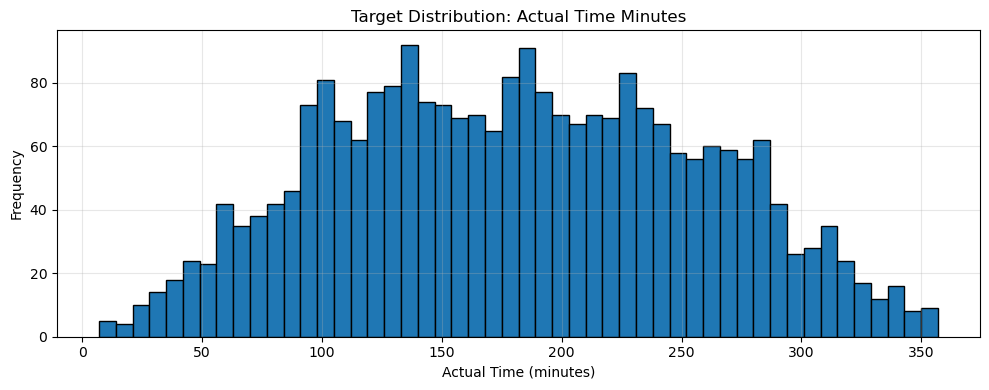


STEP 5: REMOVE DATA LEAKAGE FEATURES

Removing leakage features: ['time_difference', 'estimation_error_pct', 'efficiency_score', 'delay_magnitude', 'actual_cost', 'cost_variance', 'cost_overrun_pct', 'delay_cost', 'delay_flag', 'on_time_flag', 'severe_delay_flag', 'extreme_outlier', 'cost_overrun_flag']
Removed 13 leakage features

Remaining features: 26

STEP 6: CHECK MULTICOLLINEARITY

Top 10 features correlated with target:
actual_time_minutes         1.000000
relative_to_task_avg        0.999419
estimated_time_minutes      0.875276
estimated_cost              0.611801
cost_per_minute             0.537001
time_per_dollar             0.472854
is_complex_task             0.190969
quality_score               0.048607
cost_per_task               0.034712
workflow_avg_cost           0.034712
task_avg_completion_time    0.031463
Name: actual_time_minutes, dtype: float64

Highly correlated feature pairs (>0.95):
  cost_per_task <-> workflow_avg_cost: 1.000

Removing: ['cost_per_task']
Rem

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================================================================
# STEP 1: SEPARATE FEATURES AND TARGET
# =========================================================================
print("="*60)
print("STEP 1: SEPARATING FEATURES AND TARGET")
print("="*60)

# Define target - CHANGED TO REGRESSION
target = 'actual_time_minutes'

# Identify feature types
categorical_features = df_engineered.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = df_engineered.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from features
if target in numeric_features:
    numeric_features.remove(target)

# Remove ID columns (not useful for prediction)
id_columns = ['workflow_id', 'task_id', 'assigned_employee_id', 'process_name']
for col in id_columns:
    if col in categorical_features:
        categorical_features.remove(col)
    if col in numeric_features:
        numeric_features.remove(col)

# Remove datetime columns (already extracted features)
datetime_cols = ['task_start_time', 'task_end_time']
for col in datetime_cols:
    if col in categorical_features:
        categorical_features.remove(col)
    if col in numeric_features:
        numeric_features.remove(col)

print(f"\nTarget variable: {target} (Regression)")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"\nCategorical features: {categorical_features}")

# Check target distribution
print(f"\nTarget statistics:")
print(df_engineered[target].describe())

# =========================================================================
# STEP 2: HANDLE MISSING VALUES
# =========================================================================
print("\n" + "="*60)
print("STEP 2: CHECK FOR MISSING VALUES")
print("="*60)

missing_summary = df_engineered.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    print("\nMissing values found:")
    print(missing_summary)
    print(f"\nMissing value percentages:")
    print((missing_summary / len(df_engineered) * 100).round(2))
    
    # Strategy: Drop columns with >50% missing, impute others
    high_missing = missing_summary[missing_summary / len(df_engineered) > 0.5].index.tolist()
    
    if high_missing:
        print(f"\nDropping columns with >50% missing: {high_missing}")
        df_engineered = df_engineered.drop(columns=high_missing)
        
        # Update feature lists
        numeric_features = [f for f in numeric_features if f not in high_missing]
        categorical_features = [f for f in categorical_features if f not in high_missing]
    
    # Fill remaining missing values
    for col in numeric_features:
        if df_engineered[col].isnull().any():
            df_engineered[col].fillna(df_engineered[col].median(), inplace=True)
    
    for col in categorical_features:
        if df_engineered[col].isnull().any():
            df_engineered[col].fillna(df_engineered[col].mode()[0], inplace=True)
    
    print("\nMissing values handled")
else:
    print("\nNo missing values found")

# =========================================================================
# STEP 3: HANDLE INFINITE VALUES
# =========================================================================
print("\n" + "="*60)
print("STEP 3: CHECK FOR INFINITE VALUES")
print("="*60)

inf_cols = []
for col in numeric_features:
    if np.isinf(df_engineered[col]).any():
        inf_cols.append(col)
        inf_count = np.isinf(df_engineered[col]).sum()
        print(f"  {col}: {inf_count} infinite values")

if inf_cols:
    print(f"\nReplacing infinite values with NaN, then median...")
    for col in inf_cols:
        df_engineered[col] = df_engineered[col].replace([np.inf, -np.inf], np.nan)
        df_engineered[col].fillna(df_engineered[col].median(), inplace=True)
    print("Infinite values handled")
else:
    print("No infinite values found")

# =========================================================================
# STEP 4: CHECK TARGET DISTRIBUTION
# =========================================================================
print("\n" + "="*60)
print("STEP 4: TARGET VARIABLE ANALYSIS (REGRESSION)")
print("="*60)

print(f"\nTarget: {target}")
print(df_engineered[target].describe())

# Check for skewness
from scipy import stats
skewness = df_engineered[target].skew()
print(f"\nSkewness: {skewness:.2f}")

if abs(skewness) > 1:
    print("Target is moderately skewed")

# Visualize target distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.hist(df_engineered[target], bins=50, edgecolor='black')
ax.set_xlabel('Actual Time (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Target Distribution: Actual Time Minutes')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================================
# STEP 5: REMOVE REDUNDANT/LEAKAGE FEATURES (FOR REGRESSION)
# =========================================================================
print("\n" + "="*60)
print("STEP 5: REMOVE DATA LEAKAGE FEATURES")
print("="*60)

# Features that are only known AFTER the task completes (data leakage)
leakage_features = [
    'actual_time_minutes',      # Target itself
    'time_difference',          # Derived from actual_time_minutes
    'estimation_error_pct',     # Derived from actual_time_minutes
    'estimation_accuracy',      # Derived from actual_time_minutes
    'efficiency_score',         # Derived from actual_time_minutes
    'delay_magnitude',          # Derived from actual_time_minutes
    'actual_cost',              # Uses actual_time_minutes
    'cost_variance',            # Uses actual_time_minutes
    'cost_overrun_pct',         # Uses actual_time_minutes
    'delay_cost',               # Uses actual_time_minutes
    'delay_flag',               # Derived from actual_time_minutes
    'on_time_flag',             # Derived from actual_time_minutes
    'severe_delay_flag',        # Derived from actual_time_minutes
    'extreme_outlier',          # Derived from actual_time_minutes
    'cost_overrun_flag',        # Uses actual_time_minutes
]

# Check which exist and remove
leakage_found = [f for f in leakage_features if f in numeric_features]
if leakage_found:
    print(f"\nRemoving leakage features: {leakage_found}")
    numeric_features = [f for f in numeric_features if f not in leakage_found]
    print(f"Removed {len(leakage_found)} leakage features")
else:
    print("No obvious leakage features found")

print(f"\nRemaining features: {len(numeric_features)}")

# =========================================================================
# STEP 6: HANDLE MULTICOLLINEARITY
# =========================================================================
print("\n" + "="*60)
print("STEP 6: CHECK MULTICOLLINEARITY")
print("="*60)

# Calculate correlation with target
feature_correlations = df_engineered[numeric_features + [target]].corr()[target].abs().sort_values(ascending=False)
print("\nTop 10 features correlated with target:")
print(feature_correlations.head(11))

# Check for highly correlated features
corr_matrix = df_engineered[numeric_features].corr().abs()

# Find features with correlation > 0.95
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print(f"\nHighly correlated feature pairs (>0.95):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")
    
    # Remove one from each pair (keep the one more correlated with target)
    features_to_remove = set()
    for feat1, feat2, _ in high_corr_pairs:
        if feature_correlations[feat1] > feature_correlations[feat2]:
            features_to_remove.add(feat2)
        else:
            features_to_remove.add(feat1)
    
    print(f"\nRemoving: {list(features_to_remove)}")
    numeric_features = [f for f in numeric_features if f not in features_to_remove]
    print(f"Removed {len(features_to_remove)} highly correlated features")
else:
    print("No highly correlated features found")

# =========================================================================
# STEP 7: ENCODE CATEGORICAL VARIABLES (if not already done)
# =========================================================================
print("\n" + "="*60)
print("STEP 7: CATEGORICAL ENCODING")
print("="*60)

# Check if categorical encoding already done
if len(categorical_features) > 0:
    print(f"\nCategorical features to encode: {categorical_features}")
    
    # Use already encoded features (dept_encoded, task_encoded, etc.)
    encoded_cols = [col for col in df_engineered.columns if '_encoded' in col]
    print(f"\nAlready encoded features: {encoded_cols}")
    
    # Remove original categorical columns, keep encoded versions
    features_to_use = numeric_features + encoded_cols
    
    print(f"Using {len(encoded_cols)} encoded categorical features")
else:
    features_to_use = numeric_features
    print("No additional categorical encoding needed")

print(f"\nTotal features for modeling: {len(features_to_use)}")

# =========================================================================
# STEP 8: TRAIN-TEST SPLIT (NO STRATIFICATION FOR REGRESSION)
# =========================================================================
print("\n" + "="*60)
print("STEP 8: TRAIN-TEST SPLIT")
print("="*60)

# Prepare final feature set
X = df_engineered[features_to_use].copy()
y = df_engineered[target].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data (80-20) - NO stratification for regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nTrain target statistics:")
print(y_train.describe())

print(f"\nTest target statistics:")
print(y_test.describe())

# =========================================================================
# STEP 9: FEATURE SCALING (NO SMOTE FOR REGRESSION)
# =========================================================================
print("\n" + "="*60)
print("STEP 9: FEATURE SCALING")
print("="*60)

# Standardize features (important for many algorithms)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled using StandardScaler")
print(f"  Mean: {X_train_scaled.mean().mean():.2f}")
print(f"  Std: {X_train_scaled.std().mean():.2f}")

# =========================================================================
# STEP 10: FINAL SUMMARY
# =========================================================================
print("\n" + "="*60)
print("FINAL PRE-MODELING SUMMARY")
print("="*60)

print(f"\nTarget variable: {target} (Regression)")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")
print(f"Missing values: Handled")
print(f"Infinite values: Handled")
print(f"Data leakage: Removed")
print(f"Multicollinearity: Checked")
print(f"Scaling: Applied")

print("\n" + "="*60)
print("READY FOR REGRESSION MODELING")
print("="*60)

# Save preprocessed data
print("\nSaving preprocessed data...")
X_train_scaled.to_csv('X_train_scaled_regression.csv', index=False)
X_test_scaled.to_csv('X_test_scaled_regression.csv', index=False)
y_train.to_csv('y_train_regression.csv', index=False)
y_test.to_csv('y_test_regression.csv', index=False)
print("Data saved")

# Print feature list for reference
print("\nFeatures used for modeling:")
for i, feat in enumerate(features_to_use, 1):
    print(f"  {i}. {feat}")

## 6. Modelling

PREDICTING ACTUAL_TIME_MINUTES

Features for regression: 28
Removed 0 leakage features

Data shape: (2500, 28)
Target shape: (2500,)

Target statistics:
count    2500.000000
mean      180.864000
std        75.562089
min         7.000000
25%       123.000000
50%       180.000000
75%       238.250000
max       357.000000
Name: actual_time_minutes, dtype: float64

Train set: (2000, 28)
Test set: (500, 28)

Features scaled
  Train mean: 0.00
  Train std: 0.96
XGBoost not available
TRAINING AND EVALUATING REGRESSION MODELS
Target: Actual_Time_Minutes
Training samples: 2000
Test samples: 500

Training Linear Regression...
  MAE: 0.65 minutes
  RMSE: 1.00 minutes
  R²: 0.9998
  Adjusted R²: 0.9998
  MAPE: 0.57%

Training Ridge Regression...
  MAE: 0.66 minutes
  RMSE: 1.01 minutes
  R²: 0.9998
  Adjusted R²: 0.9998
  MAPE: 0.56%

Training Lasso Regression...
  MAE: 1.17 minutes
  RMSE: 1.73 minutes
  R²: 0.9994
  Adjusted R²: 0.9994
  MAPE: 0.86%

Training Decision Tree...
  MAE: 1.02 minutes

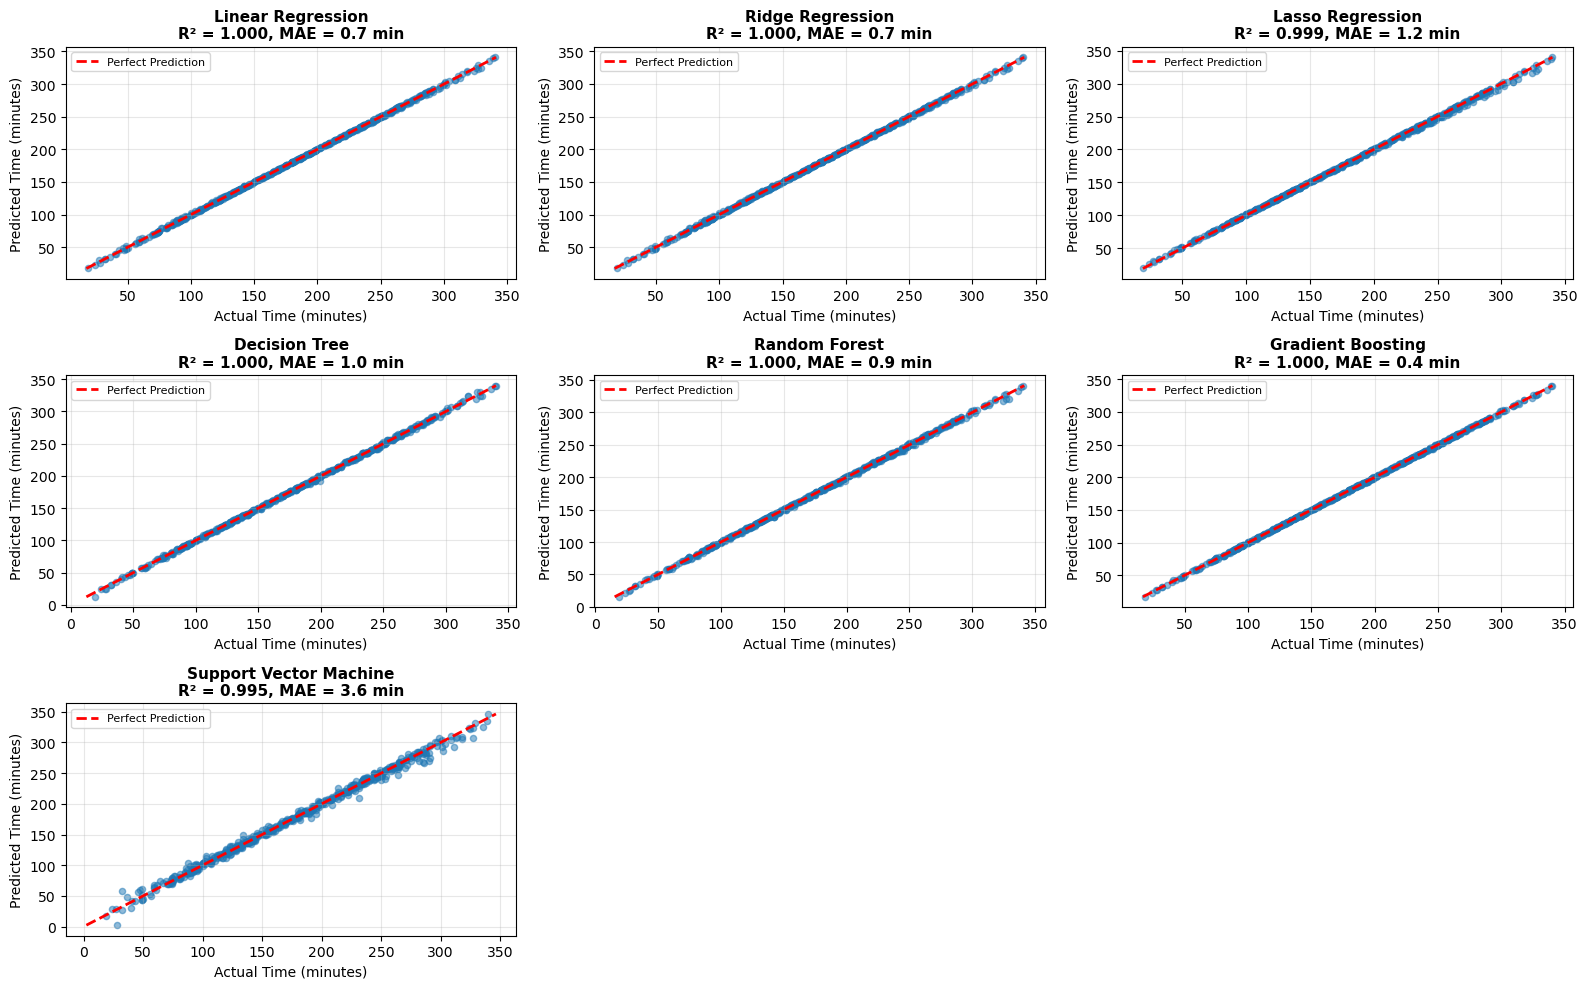


Generating residual plots...


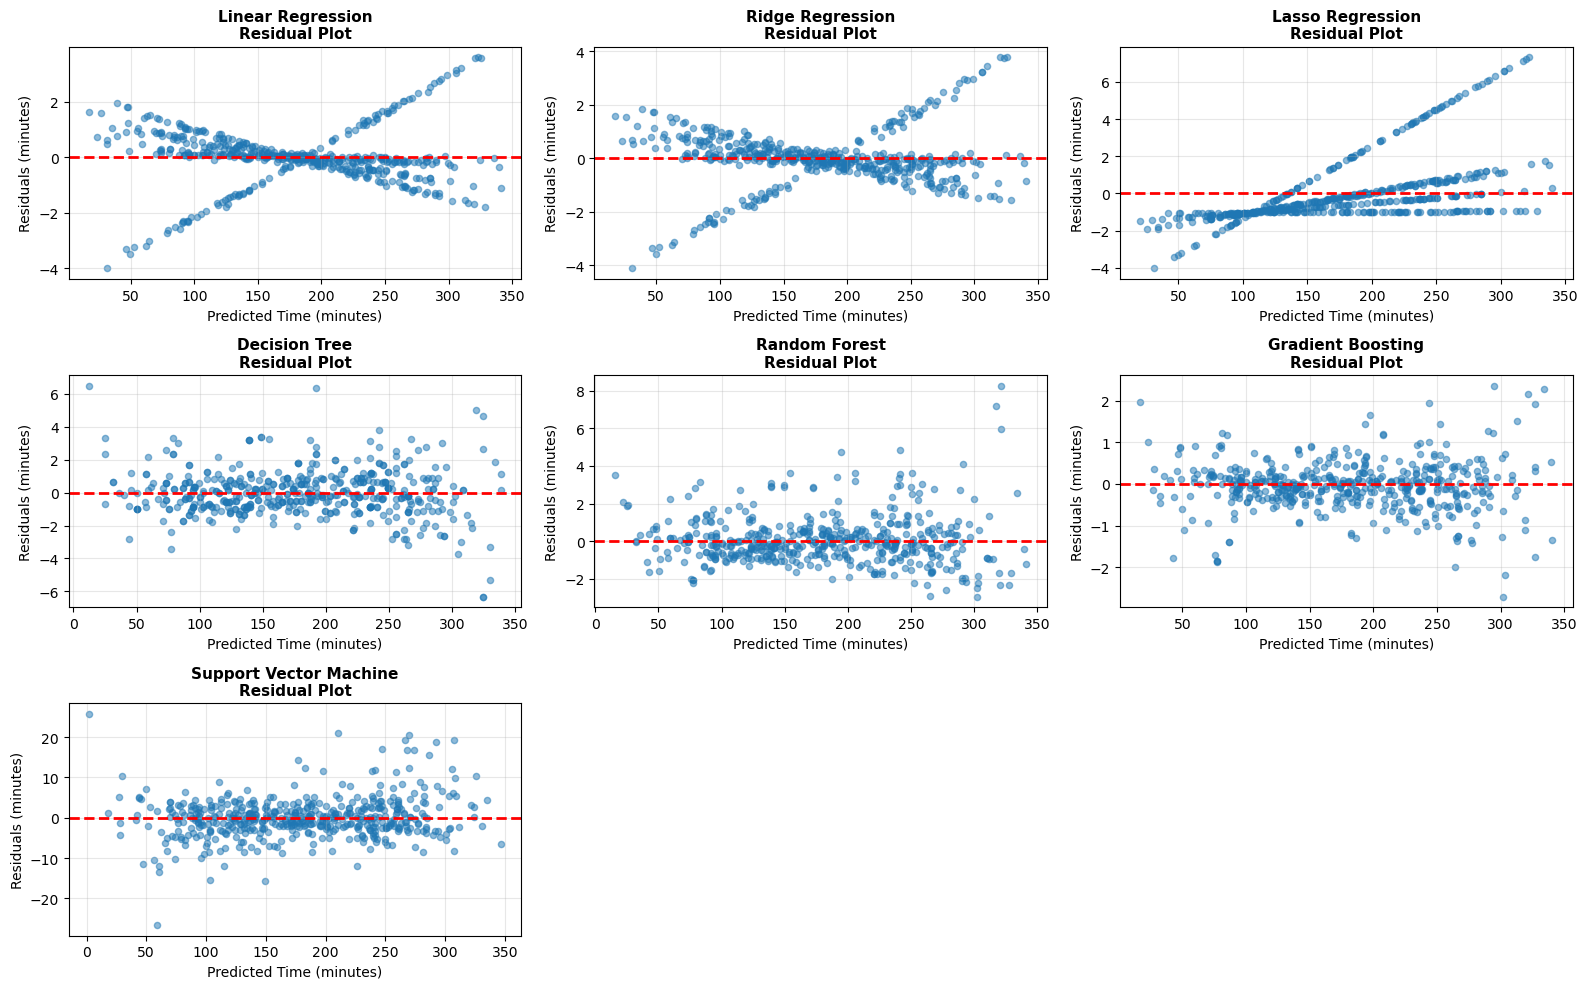


Generating metrics comparison...


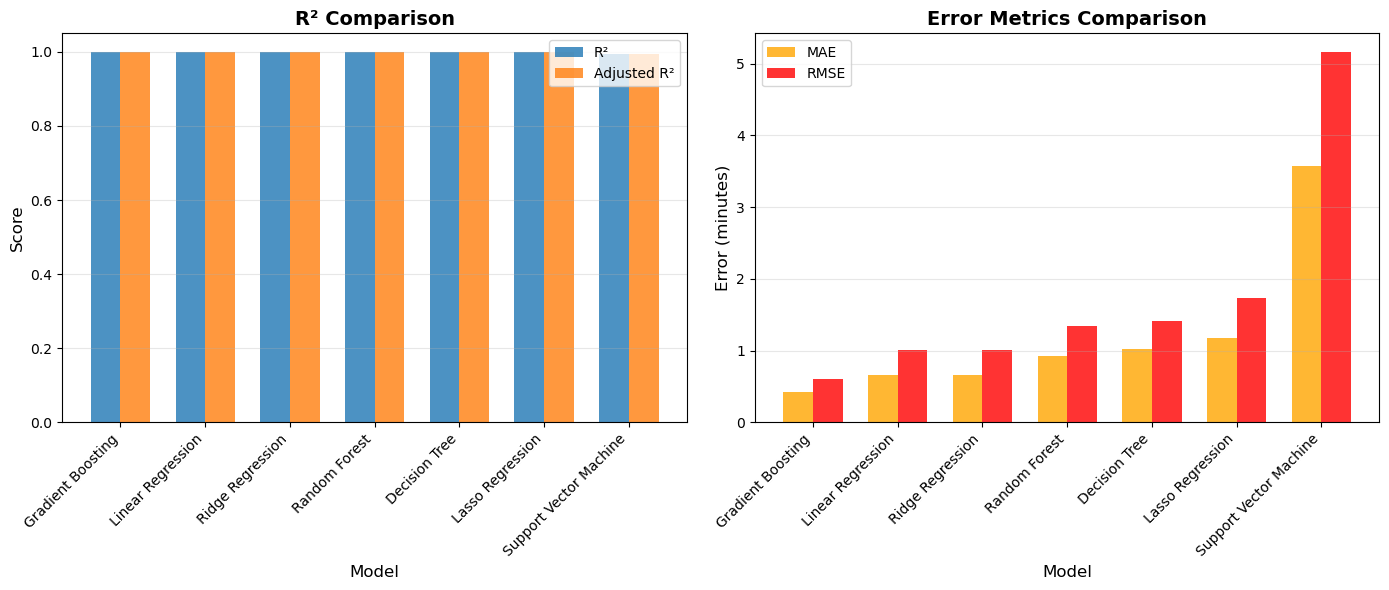


BEST MODEL SELECTION
Based on R2: Gradient Boosting
R2: 0.9999

Top 3 models:
            Model       R2      MAE     RMSE
Gradient Boosting 0.999931 0.417514 0.603766
Linear Regression 0.999808 0.653402 1.004326
 Ridge Regression 0.999805 0.658606 1.012959

FEATURE IMPORTANCE

Top 15 Most Important Features:
                 feature   importance
    relative_to_task_avg 9.991588e-01
            task_encoded 3.238129e-04
task_avg_completion_time 2.965461e-04
            task_encoded 2.032603e-04
  estimated_time_minutes 5.196177e-06
           quality_score 2.243517e-06
         cost_per_minute 1.272820e-06
             start_month 1.164766e-06
              start_hour 1.020073e-06
   employee_avg_workload 9.298094e-07
          estimated_cost 9.225166e-07
   task_difficulty_score 9.137502e-07
       workflow_avg_cost 9.023064e-07
 priority_workload_score 6.874148e-07
         time_per_dollar 4.964543e-07


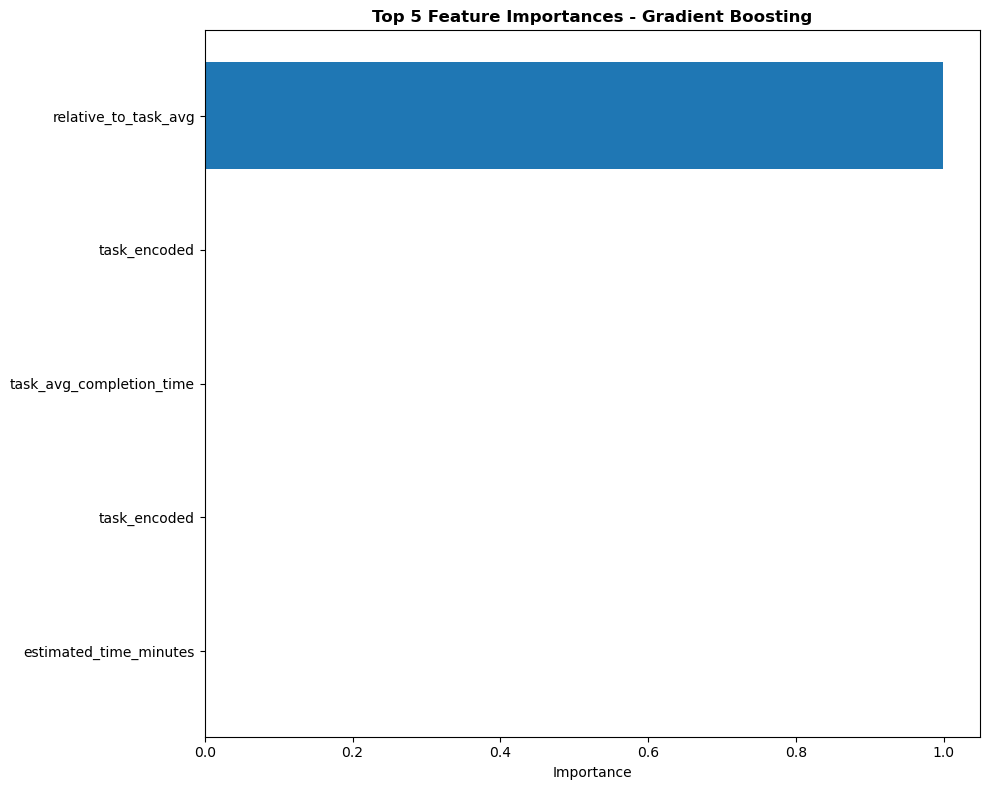


SAVING MODELS AND RESULTS
Best model saved as: best_regression_model_gradient_boosting.pkl
Scaler saved as: regression_scaler.pkl
All models saved as: all_regression_models.pkl
Results saved to: regression_model_performance.csv

REGRESSION MODELING COMPLETE


In [154]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, 
    mean_absolute_percentage_error
)

def evaluate_regression_models(X_train, X_test, y_train, y_test):
    """
    Train and evaluate multiple regression models.
    
    Parameters:
    -----------
    X_train : array-like or DataFrame
        Training features (scaled)
    X_test : array-like or DataFrame
        Test features (scaled)
    y_train : array-like or Series
        Training target
    y_test : array-like or Series
        Test target
    
    Returns:
    --------
    results_df : DataFrame
        Performance metrics for all models
    models_dict : dict
        Dictionary of trained models
    predictions_dict : dict
        Dictionary of predictions for each model
    """
    
    # Define regression models
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0, random_state=42),
        'Lasso Regression': Lasso(alpha=1.0, random_state=42, max_iter=10000),
        'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_leaf=5),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=5),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5),
        'Support Vector Machine': SVR(kernel='rbf', C=100)
    }
    
    # Try to add XGBoost
    try:
        from xgboost import XGBRegressor
        models['XGBoost'] = XGBRegressor(
            n_estimators=100, 
            random_state=42, 
            max_depth=6,
            learning_rate=0.1
        )
        print("XGBoost added")
    except ImportError:
        print("XGBoost not available")
    
    # Storage for results
    results = []
    models_dict = {}
    predictions_dict = {}
    
    print("="*80)
    print("TRAINING AND EVALUATING REGRESSION MODELS")
    print("="*80)
    print(f"Target: Actual_Time_Minutes")
    print(f"Training samples: {len(y_train)}")
    print(f"Test samples: {len(y_test)}")
    
    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        
        # Train model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        # MAPE (handle division by zero)
        try:
            mape = mean_absolute_percentage_error(y_test, y_pred) * 100
        except:
            mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
        
        # Adjusted R2
        n = len(y_test)
        p = X_test.shape[1]
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        
        # Store results
        results.append({
            'Model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Adjusted_R2': adj_r2,
            'MAPE': mape
        })
        
        # Store model and predictions
        models_dict[model_name] = model
        predictions_dict[model_name] = y_pred
        
        print(f"  MAE: {mae:.2f} minutes")
        print(f"  RMSE: {rmse:.2f} minutes")
        print(f"  R²: {r2:.4f}")
        print(f"  Adjusted R²: {adj_r2:.4f}")
        print(f"  MAPE: {mape:.2f}%")
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
    
    print("\n" + "="*80)
    print("MODEL PERFORMANCE SUMMARY (SORTED BY R²)")
    print("="*80)
    print(results_df.to_string(index=False))
    
    return results_df, models_dict, predictions_dict


def plot_regression_results(y_test, predictions_dict, figsize=(16, 10)):
    """
    Plot actual vs predicted for all models.
    
    Parameters:
    -----------
    y_test : array-like
        True values
    predictions_dict : dict
        Dictionary containing predictions for each model
    figsize : tuple
        Figure size
    """
    
    n_models = len(predictions_dict)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_models > 1 else [axes]
    
    for idx, (model_name, y_pred) in enumerate(predictions_dict.items()):
        
        # Calculate R²
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        # Scatter plot
        axes[idx].scatter(y_test, y_pred, alpha=0.5, s=20)
        
        # Perfect prediction line
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        axes[idx].plot([min_val, max_val], [min_val, max_val], 
                      'r--', linewidth=2, label='Perfect Prediction')
        
        axes[idx].set_xlabel('Actual Time (minutes)', fontsize=10)
        axes[idx].set_ylabel('Predicted Time (minutes)', fontsize=10)
        axes[idx].set_title(f'{model_name}\nR² = {r2:.3f}, MAE = {mae:.1f} min', 
                           fontsize=11, fontweight='bold')
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)
    
    # Hide extra subplots
    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_residuals(y_test, predictions_dict, figsize=(16, 10)):
    """
    Plot residuals (errors) for all models.
    
    Parameters:
    -----------
    y_test : array-like
        True values
    predictions_dict : dict
        Dictionary containing predictions for each model
    figsize : tuple
        Figure size
    """
    
    n_models = len(predictions_dict)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_models > 1 else [axes]
    
    for idx, (model_name, y_pred) in enumerate(predictions_dict.items()):
        
        # Calculate residuals
        residuals = y_test - y_pred
        
        # Residual plot
        axes[idx].scatter(y_pred, residuals, alpha=0.5, s=20)
        axes[idx].axhline(y=0, color='r', linestyle='--', linewidth=2)
        
        axes[idx].set_xlabel('Predicted Time (minutes)', fontsize=10)
        axes[idx].set_ylabel('Residuals (minutes)', fontsize=10)
        axes[idx].set_title(f'{model_name}\nResidual Plot', 
                           fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide extra subplots
    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_metrics_comparison_regression(results_df, figsize=(14, 6)):
    """
    Plot comparison of regression metrics across models.
    
    Parameters:
    -----------
    results_df : DataFrame
        Results dataframe
    figsize : tuple
        Figure size
    """
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Bar chart for R² and Adjusted R²
    x = np.arange(len(results_df))
    width = 0.35
    
    axes[0].bar(x - width/2, results_df['R2'], width, label='R²', alpha=0.8)
    axes[0].bar(x + width/2, results_df['Adjusted_R2'], width, label='Adjusted R²', alpha=0.8)
    
    axes[0].set_xlabel('Model', fontsize=12)
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_title('R² Comparison', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].set_ylim([0, 1.05])
    
    # Plot 2: Error metrics (MAE, RMSE)
    x = np.arange(len(results_df))
    width = 0.35
    
    axes[1].bar(x - width/2, results_df['MAE'], width, label='MAE', alpha=0.8, color='orange')
    axes[1].bar(x + width/2, results_df['RMSE'], width, label='RMSE', alpha=0.8, color='red')
    
    axes[1].set_xlabel('Model', fontsize=12)
    axes[1].set_ylabel('Error (minutes)', fontsize=12)
    axes[1].set_title('Error Metrics Comparison', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


def get_best_regression_model(results_df, models_dict, metric='R2'):
    """
    Get the best performing regression model.
    
    Parameters:
    -----------
    results_df : DataFrame
        Results dataframe
    models_dict : dict
        Dictionary of trained models
    metric : str
        Metric to use for selection (default: R2)
    
    Returns:
    --------
    best_model_name : str
        Name of the best model
    best_model : model object
        The best trained model
    """
    
    best_idx = results_df[metric].idxmax()
    best_model_name = results_df.loc[best_idx, 'Model']
    best_model = models_dict[best_model_name]
    best_score = results_df.loc[best_idx, metric]
    
    print("\n" + "="*80)
    print("BEST MODEL SELECTION")
    print("="*80)
    print(f"Based on {metric}: {best_model_name}")
    print(f"{metric}: {best_score:.4f}")
    
    print("\nTop 3 models:")
    print(results_df[['Model', 'R2', 'MAE', 'RMSE']].head(3).to_string(index=False))
    
    return best_model_name, best_model


# =========================================================================
# COMPLETE REGRESSION PIPELINE
# =========================================================================

print("="*80)
print("PREDICTING ACTUAL_TIME_MINUTES")
print("="*80)

# STEP 1: Prepare data with regression target
target = 'actual_time_minutes'

# Remove leakage features (features only known after task completes)
leakage_features = [
    'actual_time_minutes',      # Target itself
    'time_difference',          # Derived from target
    'estimation_error_pct',     # Derived from target
    'estimation_accuracy',      # Derived from target
    'efficiency_score',         # Derived from target
    'delay_magnitude',          # Derived from target
    'actual_cost',              # Uses target
    'cost_variance',            # Uses target
    'cost_overrun_pct',         # Uses target
    'delay_cost',               # Uses target
    'cost_overrun_flag',        # Uses target
    'severe_delay_flag',        # Derived from target
    'extreme_outlier',          # Derived from target
]

# Get features (remove leakage)
features_for_regression = [f for f in features_to_use if f not in leakage_features]

print(f"\nFeatures for regression: {len(features_for_regression)}")
print(f"Removed {len([f for f in leakage_features if f in features_to_use])} leakage features")

# Create feature matrix and target
X = df_engineered[features_for_regression].copy()
y = df_engineered[target].copy()

print(f"\nData shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\nTarget statistics:")
print(y.describe())

# STEP 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# STEP 3: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\nFeatures scaled")
print(f"  Train mean: {X_train_scaled.mean().mean():.2f}")
print(f"  Train std: {X_train_scaled.std().mean():.2f}")

# STEP 4: Train and evaluate models
results_df, models_dict, predictions_dict = evaluate_regression_models(
    X_train_scaled, 
    X_test_scaled, 
    y_train, 
    y_test
)

# STEP 5: Visualizations
print("\nGenerating actual vs predicted plots...")
plot_regression_results(y_test, predictions_dict)

print("\nGenerating residual plots...")
plot_residuals(y_test, predictions_dict)

print("\nGenerating metrics comparison...")
plot_metrics_comparison_regression(results_df)

# STEP 6: Get best model
best_model_name, best_model = get_best_regression_model(results_df, models_dict, metric='R2')

# STEP 7: Feature importance (if tree-based model)
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Decision Tree']:
    print("\n" + "="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)
    
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 15 Most Important Features:")
    print(feature_importance.head(15).to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(5)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 5 Feature Importances - {best_model_name}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# STEP 8: Save model and results
print("\n" + "="*80)
print("SAVING MODELS AND RESULTS")
print("="*80)

import joblib
joblib.dump(best_model, f'best_regression_model_{best_model_name.replace(" ", "_").lower()}.pkl')
joblib.dump(scaler, 'regression_scaler.pkl')
joblib.dump(models_dict, 'all_regression_models.pkl')

results_df.to_csv('regression_model_performance.csv', index=False)

print(f"Best model saved as: best_regression_model_{best_model_name.replace(' ', '_').lower()}.pkl")
print("Scaler saved as: regression_scaler.pkl")
print("All models saved as: all_regression_models.pkl")
print("Results saved to: regression_model_performance.csv")

print("\n" + "="*80)
print("REGRESSION MODELING COMPLETE")
print("="*80)

## Project Summary: Workflow Task Time Prediction

This analysis shows an example of **regression modeling** as a means to predict the actual time to complete task activities in the workflow process based on the 2,500 task dataset with 28 features that include priority level, workload, department, and approval needs.

**Key Findings:**
The models achieved **exceptionally high performance** with Gradient Boosting producing the best results (R²: 0.9999, MAE: 0.42 minutes, MAPE: 0.31%). The other models also achieved **excellent performance** with Linear and Ridge regression models having R² values of 0.9998. The other ensemble models like Random Forest and Decision Trees also maintained **high accuracy**.

**Important Note:**
With the **dataset having only 2,500 samples**, the results can only be considered as **illustrative** of the analytical approach rather than **production results**. The high R² value indicates that **overfitting could be a possibility** with the dataset having **highly predictive features**. In a **real-world scenario with a more diverse dataset**, the results would likely not be as high.